# Datasets

### Dataset Split Summary

This analysis summarizes how each processed dataset is partitioned for the experiments.
The available samples are assigned to three possible splits:

- **Pretrain** contains data used during the initial model pretraining stage.
- **Validation** contains held-out data used to evaluate model performance.
- **Simulation** contains data assigned to the nodes participating in the
  opportunistic learning simulation.

The partitioning is performed at the subject level. Consequently, samples from
the same subject are not shared across different splits, reducing the risk of
data leakage.

For every dataset and split, the table reports:

- the number of samples;
- the number of distinct subjects;
- the number of represented classes;
- the number of devices;
- the percentage of the dataset assigned to that split.

Differences between sample percentages and subject percentages are expected,
because subjects may contribute different numbers of samples.

In [3]:
from pathlib import Path
import pandas as pd

PROCESSED_DIR = Path("../data/processed")
SPLIT_ORDER = ["pretrain", "simulation", "validation", "unused"]

frames = []

for dataset_dir in sorted(PROCESSED_DIR.iterdir()):
    manifest_path = dataset_dir / "manifest.csv"

    if not dataset_dir.is_dir() or not manifest_path.exists():
        continue

    part = pd.read_csv(manifest_path)
    part["dataset"] = dataset_dir.name
    frames.append(part)

manifest_df = pd.concat(frames, ignore_index=True)

manifest_df["split"] = pd.Categorical(
    manifest_df["split"],
    categories=SPLIT_ORDER,
    ordered=True,
)

split_summary = (
    manifest_df
    .groupby(["dataset", "split"], observed=True)
    .agg(
        samples=("sample_index", "size"),
        subjects=("subject_id", "nunique"),
        classes=("label", "nunique"),
        devices=("device_id", "nunique"),
    )
    .reset_index()
)

split_summary["samples_%"] = (
    100
    * split_summary["samples"]
    / split_summary.groupby("dataset")["samples"].transform("sum")
)

split_summary = split_summary.sort_values(["dataset", "split"])

display(
    split_summary.style
    .format({
        "samples": "{:,.0f}",
        "subjects": "{:,.0f}",
        "classes": "{:,.0f}",
        "devices": "{:,.0f}",
        "samples_%": "{:.1f}%",
    })
    .background_gradient(
        subset=["samples_%"],
        cmap="Blues",
    )
)

,dataset,split,samples,subjects,classes,devices,samples_%
0,hhar,simulation,"87,634",9,6,8,100.0%
1,sisfall,pretrain,"29,187",22,2,1,53.0%
2,sisfall,simulation,"16,070",10,2,1,29.2%
3,sisfall,validation,"9,832",6,2,1,17.8%
4,uci_har,pretrain,"8,921",26,6,1,86.6%
5,uci_har,validation,"1,378",4,6,1,13.4%
6,wesad,pretrain,204,3,3,1,19.9%
7,wesad,simulation,682,10,3,1,66.5%
8,wesad,validation,140,2,3,1,13.6%


The processed datasets have different roles in the experimental workflow:

- **[HHAR](https://archive.ics.uci.edu/dataset/344/heterogeneity%2Bactivity%2Brecognition)** contains accelerometer and gyroscope measurements collected from smartphones and smartwatches while nine participants performed six activities. Its 87,634 samples are assigned entirely to the simulation split. HHAR is also the only dataset in this group containing data from multiple device models.

- **[SisFall](https://pmc.ncbi.nlm.nih.gov/articles/PMC5298771/)** contains wearable inertial measurements of falls and activities of daily living. It is divided into pretraining (53.0%), simulation (29.2%), and validation (17.8%). All three splits contain both processed classes.

- **[UCI HAR](https://archive.ics.uci.edu/dataset/240/humanactivityrecognitionusingsmartphones)** contains smartphone accelerometer and gyroscope recordings from 30 participants performing six daily activities. It is used for pretraining (86.6%) and validation (13.4%), but not as a source of simulated nodes.

- **[WESAD](https://archive.ics.uci.edu/dataset/465/wesad%2Bwearable%2Bstress%2Band%2Baffect%2Bdetection)** contains physiological and motion signals recorded using wrist- and chest-worn devices during neutral, stress, and amusement conditions. Most samples are assigned to simulation (66.5%), while the remaining data are used for pretraining (19.9%) and validation (13.6%).

All available splits preserve the complete set of processed classes for their respective datasets. The different sample proportions reflect the experimental role of each dataset and the number of samples contributed by individual subjects. Because partitioning is performed at the subject level, exact sample percentages are not expected to match across datasets.

### Class Distribution Across Experimental Splits

The following stacked bar chart shows the class distribution within each available dataset split. Every bar represents one dataset–split combination and sums to 100%.

The split abbreviations are:

- **PRE**: pretraining;
- **VAL**: validation;
- **SIM**: simulation.

Colors and hatch patterns identify the processed class labels. Class identifiers are local to each dataset: for example, `Class 0` does not necessarily represent the same activity or state in HHAR, SisFall, UCI HAR, and WESAD. Consequently, comparisons should primarily be made between the splits of the same dataset.

This visualization is intended to reveal class imbalance and verify whether the class distribution remains consistent across pretraining, simulation, and validation data.

/tmp/ipykernel_2444483/3259552962.py:47: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  distribution_table["split"] = pd.Categorical(


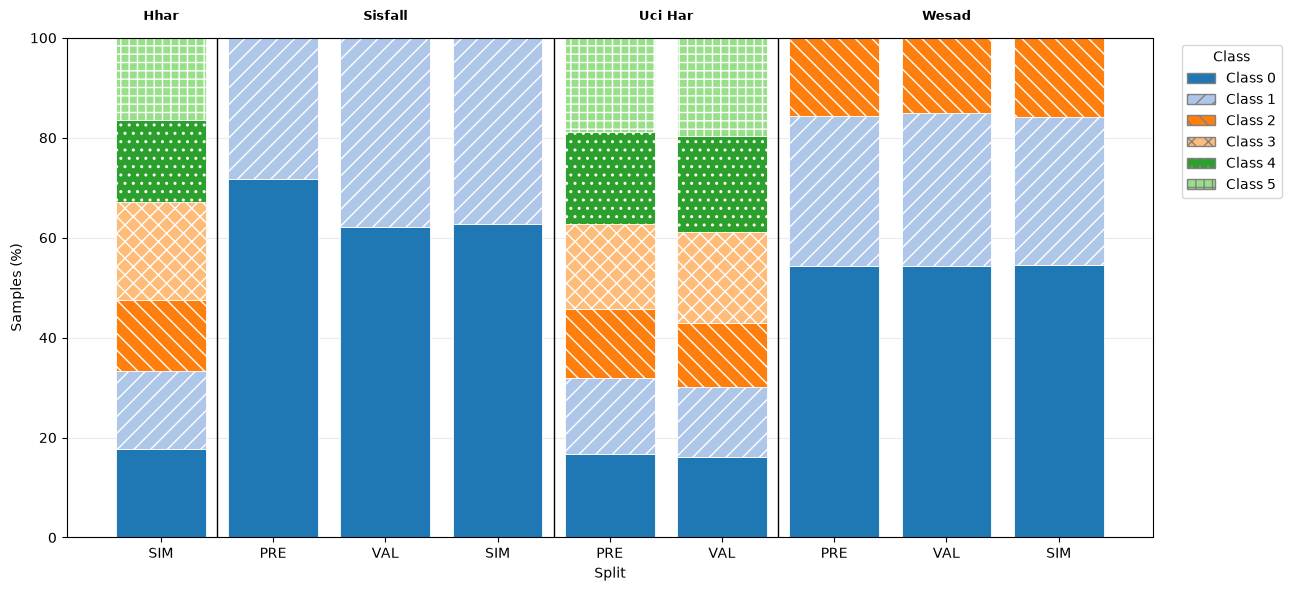

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns

SPLIT_ORDER = ["pretrain", "validation", "simulation"]

SPLIT_LABELS = {
    "pretrain": "PRE",
    "validation": "VAL",
    "simulation": "SIM",
}

# Keep only the splits shown in the plot
plot_df = manifest_df[
    manifest_df["split"].isin(SPLIT_ORDER)
].copy()

# Compute the class distribution within each dataset and split
class_distribution = (
    plot_df
    .groupby(["dataset", "split", "label"], observed=True)
    .size()
    .rename("samples")
    .reset_index()
)

class_distribution["percentage"] = (
    100
    * class_distribution["samples"]
    / class_distribution
        .groupby(["dataset", "split"])["samples"]
        .transform("sum")
)

# Create one row for each available dataset-split combination
distribution_table = class_distribution.pivot_table(
    index=["dataset", "split"],
    columns="label",
    values="percentage",
    fill_value=0,
    observed=True,
).reset_index()

# Sort splits according to the desired order
distribution_table["split"] = pd.Categorical(
    distribution_table["split"],
    categories=SPLIT_ORDER,
    ordered=True,
)

distribution_table = (
    distribution_table
    .sort_values(["dataset", "split"])
    .set_index(["dataset", "split"])
)

class_labels = distribution_table.columns.tolist()
positions = np.arange(len(distribution_table))

# Use colors and hatch patterns to distinguish classes
colors = sns.color_palette("tab20", n_colors=len(class_labels))
hatches = [
    "", "//", "\\\\", "xx", "..", "++",
    "oo", "**", "--", "||", "OO", "XX",
]

fig, ax = plt.subplots(
    figsize=(max(13, len(distribution_table) * 0.55), 6)
)

bottom = np.zeros(len(distribution_table))
legend_patches = []

for index, (class_label, color) in enumerate(zip(class_labels, colors)):
    values = distribution_table[class_label].to_numpy()
    hatch = hatches[index % len(hatches)]

    ax.bar(
        positions,
        values,
        bottom=bottom,
        width=0.8,
        color=color,
        hatch=hatch,
        edgecolor="white",
        linewidth=0.6,
    )

    legend_patches.append(
        Patch(
            facecolor=color,
            edgecolor="gray",
            hatch=hatch,
            label=f"Class {class_label}",
        )
    )

    bottom += values

# Display short, horizontal split labels
ax.set_xticks(positions)
ax.set_xticklabels(
    [
        SPLIT_LABELS.get(str(split), str(split).upper())
        for _, split in distribution_table.index
    ],
    rotation=0,
    ha="center",
)

ax.set_xlabel("Split")
ax.set_ylabel("Samples (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

# Add dataset names and separators
dataset_values = distribution_table.index.get_level_values("dataset")

for dataset in dataset_values.unique():
    dataset_positions = np.flatnonzero(dataset_values == dataset)
    center = dataset_positions.mean()

    ax.text(
        center,
        103,
        dataset.replace("_", " ").title(),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        clip_on=False,
    )

    if dataset_positions[-1] < len(distribution_table) - 1:
        ax.axvline(
            dataset_positions[-1] + 0.5,
            color="black",
            linewidth=1,
            alpha=1,
        )

# Create an explicit patch-based legend
ax.legend(
    handles=legend_patches,
    title="Class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

The datasets exhibit different levels of class balance:

- **HHAR** contains six relatively balanced activity classes. Their proportions range from approximately 14.2% to 19.5% in the simulation split.

- **SisFall** is a binary dataset with a marked class imbalance. Class 0 represents approximately 62–72% of the samples, depending on the split. The imbalance is stronger in pretraining than in simulation and validation.

- **UCI HAR** contains six activity classes with moderately balanced distributions. The validation split follows a distribution similar to pretraining, although some differences are visible for individual classes.

- **WESAD** contains three processed affective-state classes and shows a stable imbalance across all splits. Class 0 represents approximately 54% of the samples, Class 1 approximately 30%, and Class 2 approximately 15–16%.

Overall, the class proportions remain reasonably consistent across the available splits of each dataset. This suggests that subject-level partitioning preserves the main class structure, although it cannot guarantee identical distributions because different subjects may contribute different amounts of data for each class.

In [6]:
# Summary of all datasets used in the study.
# Statistics are computed over all samples present in each manifest.

datasets_df = manifest_df.copy()

dataset_summary = (
    datasets_df
    .groupby("dataset", observed=True)
    .agg(
        subjects=("subject_id", "nunique"),
        devices=("device_id", "nunique"),
        samples=("sample_index", "size"),
        classes=("label", "nunique"),
    )
    .reset_index()
)

# Identify the majority class and its prevalence within each dataset
class_counts = (
    datasets_df
    .groupby(["dataset", "label"], observed=True)
    .size()
    .rename("class_samples")
    .reset_index()
)

majority_class = (
    class_counts
    .sort_values(
        ["dataset", "class_samples"],
        ascending=[True, False],
    )
    .groupby("dataset", observed=True)
    .first()
    .reset_index()
    .rename(columns={
        "label": "majority_class",
        "class_samples": "majority_samples",
    })
)

dataset_summary = dataset_summary.merge(
    majority_class[
        ["dataset", "majority_class", "majority_samples"]
    ],
    on="dataset",
)

dataset_summary["majority_class_pct"] = (
    100
    * dataset_summary["majority_samples"]
    / dataset_summary["samples"]
)

# Information to display in the paper
DATASET_INFO = {
    "uci_har": {
        "name": "UCI HAR",
        "application": "Activity recognition",
        "role": "Pretraining",
        "sensors": "Smartphone accelerometer",
    },
    "hhar": {
        "name": "HHAR",
        "application": "Activity recognition",
        "role": "Simulation",
        "sensors": "Smartphone/watch accelerometer",
    },
    "sisfall": {
        "name": "SisFall",
        "application": "Fall detection",
        "role": "Simulation",
        "sensors": "Accelerometer and gyroscope",
    },
    "wesad": {
        "name": "WESAD",
        "application": "Stress recognition",
        "role": "Simulation",
        "sensors": "Physiological and motion signals",
    },
}

def dataset_info(dataset, field, default="--"):
    return DATASET_INFO.get(dataset, {}).get(field, default)

paper_dataset_summary = dataset_summary.assign(
    Dataset=lambda df: df["dataset"].map(
        lambda dataset: dataset_info(
            dataset,
            "name",
            dataset.replace("_", " ").title(),
        )
    ),
    Application=lambda df: df["dataset"].map(
        lambda dataset: dataset_info(dataset, "application")
    ),
    Role=lambda df: df["dataset"].map(
        lambda dataset: dataset_info(dataset, "role")
    ),
    Sensors=lambda df: df["dataset"].map(
        lambda dataset: dataset_info(dataset, "sensors")
    ),
)[
    [
        "Dataset",
        "Application",
        "Role",
        "Sensors",
        "subjects",
        "devices",
        "samples",
        "classes",
        "majority_class",
        "majority_class_pct",
    ]
].rename(columns={
    "subjects": "Subjects",
    "devices": "Devices",
    "samples": "Samples",
    "classes": "Classes",
    "majority_class": "Majority class",
    "majority_class_pct": "Majority class (%)",
})

display(
    paper_dataset_summary.style.format({
        "Subjects": "{:,.0f}",
        "Devices": "{:,.0f}",
        "Samples": "{:,.0f}",
        "Classes": "{:,.0f}",
        "Majority class (%)": "{:.1f}%",
    })
)

,Dataset,Application,Role,Sensors,Subjects,Devices,Samples,Classes,Majority class,Majority class (%)
0,HHAR,Activity recognition,Simulation,Smartphone/watch accelerometer,9,8,"87,634",6,3,19.5%
1,SisFall,Fall detection,Simulation,Accelerometer and gyroscope,38,1,"55,089",2,0,67.4%
2,UCI HAR,Activity recognition,Pretraining,Smartphone accelerometer,30,1,"10,299",6,5,18.9%
3,WESAD,Stress recognition,Simulation,Physiological and motion signals,15,1,"1,026",3,0,54.5%


### Pretraining

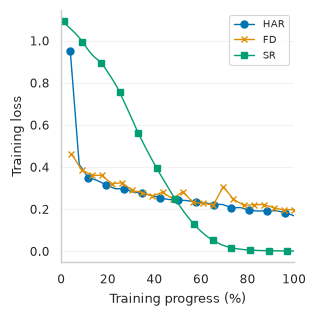

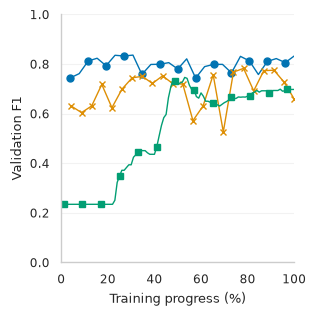

In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

CHECKPOINT_DIR = Path("../data/checkpoints")
OUTPUT_DIR = Path("../plots")

SCENARIOS = {
    "HAR": {
        "keywords": ("uci_har", "ucihar"),
        "label": "HAR",
    },
    "Fall detection": {
        "keywords": ("sisfall",),
        "label": "FD",
    },
    "Stress recognition": {
        "keywords": ("wesad",),
        "label": "SR",
    },
}

# Find CSV files containing epoch-level pretraining metrics.
candidates = []

for csv_path in CHECKPOINT_DIR.rglob("*.csv"):
    try:
        columns = pd.read_csv(csv_path, nrows=3).columns
    except Exception:
        continue

    if {"epoch", "train_loss", "eval_f1"}.issubset(columns):
        candidates.append(csv_path)

if not candidates:
    raise FileNotFoundError(
        f"No suitable training logs found in {CHECKPOINT_DIR.resolve()}."
    )

def select_log(keywords):
    matches = [
        path for path in candidates
        if any(keyword in str(path).lower() for keyword in keywords)
    ]

    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one log for {keywords}, but found:\n"
            + "\n".join(f" - {path}" for path in matches)
        )

    return matches[0]

selected_logs = {
    scenario: select_log(info["keywords"])
    for scenario, info in SCENARIOS.items()
}

# Load metrics and normalize epochs independently for each pretraining run.
curves = {}

for scenario, log_path in selected_logs.items():
    metrics = pd.read_csv(log_path).sort_values("epoch").copy()

    max_epoch = metrics["epoch"].max()
    metrics["training_progress"] = 100 * metrics["epoch"] / max_epoch

    curves[scenario] = metrics

sns.set_theme(style="whitegrid", context="paper")
colors = sns.color_palette("colorblind", n_colors=len(curves))
markers = ["o", "x", "s"]

FIGSIZE = (3.25, 3.25)

# ---- Figure 1: training loss ----
fig_loss, ax_loss = plt.subplots(figsize=FIGSIZE)

for color, marker, (scenario, metrics) in zip(colors, markers, curves.items()):
    ax_loss.plot(
        metrics["training_progress"],
        metrics["train_loss"],
        label=SCENARIOS[scenario]["label"],
        color=color,
        linewidth=1.0,
        marker=marker,
        markersize=5.0,
        markevery=max(1, len(metrics) // 12),
    )

ax_loss.set_xlabel("Training progress (%)")
ax_loss.set_ylabel("Training loss")
ax_loss.set_xlim(0, 100)
ax_loss.grid(axis="y", alpha=0.25)
ax_loss.grid(axis="x", visible=False)
ax_loss.legend(
    loc="upper right",
    frameon=True,
    fontsize=7.5,
)
sns.despine(ax=ax_loss)

fig_loss.tight_layout()

# ---- Figure 2: validation F1-score ----
fig_f1, ax_f1 = plt.subplots(figsize=FIGSIZE)

for color, marker, (scenario, metrics) in zip(colors, markers, curves.items()):
    ax_f1.plot(
        metrics["training_progress"],
        metrics["eval_f1"],
        color=color,
        linewidth=1.0,
        marker=marker,
        markersize=5.0,
        markevery=max(1, len(metrics) // 12),
    )

ax_f1.set_xlabel("Training progress (%)")
ax_f1.set_ylabel("Validation F1")
ax_f1.set_xlim(0, 100)
ax_f1.set_ylim(0, 1)
ax_f1.grid(axis="y", alpha=0.25)
ax_f1.grid(axis="x", visible=False)
sns.despine(ax=ax_f1)

fig_f1.tight_layout()

# Optional paper exports
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fig_loss.savefig(
    OUTPUT_DIR / "pretraining_loss.pdf",
    dpi=300,
    bbox_inches="tight",
)
fig_f1.savefig(
    OUTPUT_DIR / "pretraining_validation_f1.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Contact Traces

### Summary

The experiments use synthetic and real contact traces to determine when pairs of nodes can communicate.

The synthetic evaluation combines two complementary mobility models with two density regimes:

- **Community** generates contacts around a fixed community structure; most interactions occur within communities.
- **Edge-Markov** models each link as a temporally evolving process with persistent contact episodes.
- **Dense** and **Sparse** traces respectively provide frequent and infrequent contact opportunities. Within each mobility model, the two regimes retain the same community locality or temporal persistence, isolating the effect of contact density.

For every model--regime combination, we generate three realizations using seeds 7, 42, and 123. The **Cambridge/Haggle** trace provides a real-world comparison, using Bluetooth encounters recorded by iMotes carried by members of a research group at the University of Cambridge Computer Laboratory.

For each trace, the table reports:

- **Nodes**: distinct nodes appearing in the trace.
- **Events**: pairwise contact opportunities.
- **Unique pairs**: node pairs that meet at least once.
- **Possible pairs**: all undirected pairs, $N(N-1)/2$.
- **Pair coverage**: possible pairs observed at least once.
- **Duration**, **time step**, and **snapshots**: temporal resolution and extent.
- **Events per snapshot** and **pair occupancy**: normalized contact-density measures.

Repeated observations of the same undirected pair at the same timestamp are removed before computing these statistics.


In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd

MOBILITY_DIR = Path("../data/mobility")

TRACE_PATTERN = re.compile(
    r"^(community|edge_markov)_(dense|sparse)_seed(\d+)$"
)

SYNTHETIC_SCENARIOS = [
    ("Community", "Dense", "community_dense"),
    ("Community", "Sparse", "community_sparse"),
    ("Edge-Markov", "Dense", "edge_markov_dense"),
    ("Edge-Markov", "Sparse", "edge_markov_sparse"),
]

EXPECTED_SYNTHETIC_TRACES = {
    f"{prefix}_seed{seed}"
    for _, _, prefix in SYNTHETIC_SCENARIOS
    for seed in (7, 42, 123)
}


def load_summary(summary_path):
    if not summary_path.exists():
        return {}

    with summary_path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def infer_time_step(trace, summary):
    for key in ("time_step", "snapshot_step_seconds"):
        if key in summary:
            return int(summary[key])

    unique_times = np.sort(trace["time"].unique())
    differences = np.diff(unique_times)
    positive_differences = differences[differences > 0]

    if len(positive_differences) == 0:
        raise ValueError("The trace does not contain enough timestamps.")

    return int(np.gcd.reduce(positive_differences.astype(int)))


trace_rows = []
loaded_traces = {}

for trace_path in sorted(MOBILITY_DIR.glob("*.csv")):
    trace_name = trace_path.stem
    match = TRACE_PATTERN.fullmatch(trace_name)

    if trace_name == "cambridge":
        model = "Real"
        density = "Real"
        seed = np.nan
    elif match:
        raw_model, raw_density, seed = match.groups()
        model = {
            "community": "Community",
            "edge_markov": "Edge-Markov",
        }[raw_model]
        density = raw_density.title()
        seed = int(seed)
    else:
        print(f"Ignoring unrecognized or legacy trace: {trace_path.name}")
        continue

    trace = pd.read_csv(trace_path)

    required_columns = {"time", "node1", "node2"}
    missing_columns = required_columns - set(trace.columns)
    if missing_columns:
        raise ValueError(
            f"{trace_path.name} is missing columns: {sorted(missing_columns)}"
        )

    trace = trace.loc[trace["node1"] != trace["node2"]].copy()
    trace["time"] = pd.to_numeric(trace["time"], errors="raise").astype(int)

    trace[["node1", "node2"]] = np.sort(
        trace[["node1", "node2"]].astype(str).to_numpy(),
        axis=1,
    )
    trace = (
        trace.drop_duplicates(["time", "node1", "node2"])
        .sort_values(["time", "node1", "node2"])
        .reset_index(drop=True)
    )

    summary = load_summary(trace_path.with_suffix(".summary.json"))
    time_step = infer_time_step(trace, summary)

    nodes = sorted(set(trace["node1"]) | set(trace["node2"]))
    num_nodes = len(nodes)
    possible_pairs = num_nodes * (num_nodes - 1) // 2

    start_time = int(trace["time"].min())
    end_time = int(trace["time"].max())
    duration = end_time - start_time
    num_snapshots = duration // time_step + 1
    unique_pairs = trace[["node1", "node2"]].drop_duplicates().shape[0]
    events_per_snapshot = len(trace) / num_snapshots
    pair_occupancy = (
        100 * len(trace) / (num_snapshots * possible_pairs)
        if possible_pairs else np.nan
    )

    trace_rows.append({
        "trace": trace_name,
        "model": model,
        "density": density,
        "seed": seed,
        "nodes": num_nodes,
        "events": len(trace),
        "unique_pairs": unique_pairs,
        "possible_pairs": possible_pairs,
        "pair_coverage_%": 100 * unique_pairs / possible_pairs,
        "duration_hours": duration / 3600,
        "time_step_s": time_step,
        "snapshots": num_snapshots,
        "events_per_snapshot": events_per_snapshot,
        "pair_occupancy_%": pair_occupancy,
    })
    loaded_traces[trace_name] = trace

trace_summary = pd.DataFrame(trace_rows)

trace_summary["model"] = pd.Categorical(
    trace_summary["model"],
    categories=["Community", "Edge-Markov", "Real"],
    ordered=True,
)
trace_summary["density"] = pd.Categorical(
    trace_summary["density"],
    categories=["Dense", "Sparse", "Real"],
    ordered=True,
)
trace_summary = (
    trace_summary.sort_values(["model", "density", "seed"], na_position="last")
    .reset_index(drop=True)
)

available_synthetic = set(trace_summary.loc[trace_summary["model"] != "Real", "trace"])
missing_synthetic = sorted(EXPECTED_SYNTHETIC_TRACES - available_synthetic)

if missing_synthetic:
    print("Missing expected synthetic traces:")
    for trace_name in missing_synthetic:
        print(f"  - {trace_name}.csv")
else:
    print("All 12 expected synthetic traces are available.")

display(
    trace_summary.style
    .format({
        "seed": lambda value: "" if pd.isna(value) else f"{int(value)}",
        "nodes": "{:,.0f}",
        "events": "{:,.0f}",
        "unique_pairs": "{:,.0f}",
        "possible_pairs": "{:,.0f}",
        "pair_coverage_%": "{:.1f}%",
        "duration_hours": "{:.1f}",
        "time_step_s": "{:,.0f}",
        "snapshots": "{:,.0f}",
        "events_per_snapshot": "{:.3f}",
        "pair_occupancy_%": "{:.2f}%",
    })
    .background_gradient(
        subset=["events_per_snapshot", "pair_occupancy_%"],
        cmap="Blues",
    )
)


All 12 expected synthetic traces are available.


,trace,model,density,seed,nodes,events,unique_pairs,possible_pairs,pair_coverage_%,duration_hours,time_step_s,snapshots,events_per_snapshot,pair_occupancy_%
0,community_dense_seed7,Community,Dense,7,10,"20,718",45,45,100.0%,24.0,20,"4,321",4.795,10.65%
1,community_dense_seed42,Community,Dense,42,10,"21,061",45,45,100.0%,24.0,20,"4,321",4.874,10.83%
2,community_dense_seed123,Community,Dense,123,10,"20,923",45,45,100.0%,24.0,20,"4,321",4.842,10.76%
3,community_sparse_seed7,Community,Sparse,7,10,"4,208",45,45,100.0%,24.0,20,"4,321",0.974,2.16%
4,community_sparse_seed42,Community,Sparse,42,10,"4,236",45,45,100.0%,24.0,20,"4,318",0.981,2.18%
5,community_sparse_seed123,Community,Sparse,123,10,"4,090",45,45,100.0%,24.0,20,"4,321",0.947,2.10%
6,edge_markov_dense_seed7,Edge-Markov,Dense,7,10,"19,378",45,45,100.0%,24.0,20,"4,321",4.485,9.97%
7,edge_markov_dense_seed42,Edge-Markov,Dense,42,10,"19,763",45,45,100.0%,24.0,20,"4,321",4.574,10.16%
8,edge_markov_dense_seed123,Edge-Markov,Dense,123,10,"19,263",45,45,100.0%,24.0,20,"4,321",4.458,9.91%
9,edge_markov_sparse_seed7,Edge-Markov,Sparse,7,10,"3,528",45,45,100.0%,24.0,20,"4,321",0.816,1.81%


All synthetic traces contain 10 nodes, span 24 hours, and use a 20-second time step. Their three realizations have closely aligned statistics, showing that the regimes are stable across random seeds.

The Dense traces contain roughly 4.5--4.9 contact events per snapshot, corresponding to about 10\% mean pair occupancy. The Sparse traces contain approximately 0.8--1.0 contacts per snapshot and about 2\% occupancy. Thus, the sparse regime reduces the rate of peer opportunities by about a factor of five. Within each mobility model, this change does not alter the intended structural property: Community traces retain their predominantly intra-community interactions, while Edge-Markov traces retain persistent contact episodes.

The Cambridge trace differs from the synthetic traces: it contains 12 nodes, spans about 126.6 hours, and uses a 120-second observation step. Its 2.735 events per snapshot and 4.14\% pair occupancy place its average density between the synthetic regimes, although its activity is temporally irregular. Raw event counts are therefore not directly comparable across the real and synthetic traces; events per snapshot and pair occupancy provide the appropriate normalized comparison.

All traces achieve 100\% pair coverage over their complete duration. This only means that every possible pair meets at least once; it does not imply simultaneous connectivity or equally frequent interactions.


### Contact Density Comparison

The figure compares the four synthetic trace families and the Cambridge trace using the normalized density measures in the summary table. Synthetic bars report the mean over the three mobility realizations. Colors identify the trace model, while hatching distinguishes Dense and Sparse regimes.


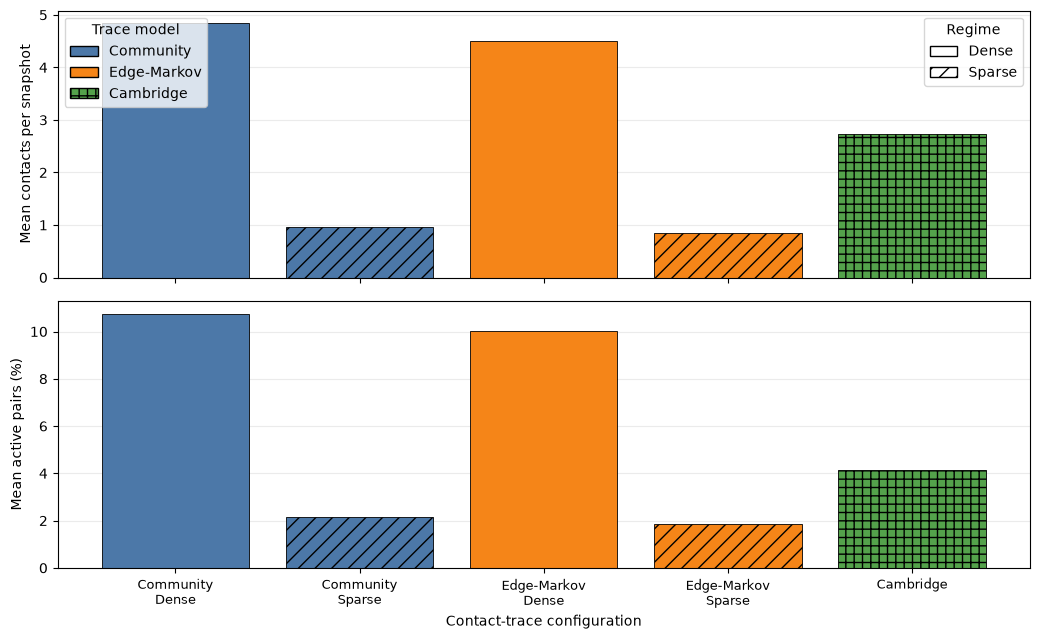

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

SYNTHETIC_ORDER = [
    ("Community", "Dense"),
    ("Community", "Sparse"),
    ("Edge-Markov", "Dense"),
    ("Edge-Markov", "Sparse"),
]

MODEL_COLORS = {
    "Community": "#4C78A8",
    "Edge-Markov": "#F58518",
    "Real": "#54A24B",
}
DENSITY_HATCHES = {"Dense": "", "Sparse": "//", "Real": "++"}

synthetic_summary = (
    trace_summary.loc[trace_summary["model"] != "Real"]
    .groupby(["model", "density"], observed=True)[
        ["events_per_snapshot", "pair_occupancy_%"]
    ]
    .mean()
    .reindex(pd.MultiIndex.from_tuples(SYNTHETIC_ORDER, names=["model", "density"]))
    .reset_index()
)

cambridge_summary = trace_summary.loc[trace_summary["model"] == "Real"].copy()
plot_df = pd.concat([synthetic_summary, cambridge_summary], ignore_index=True)
plot_df["label"] = np.where(
    plot_df["model"].eq("Real"),
    "Cambridge",
    plot_df["model"].astype(str) + "\n" + plot_df["density"].astype(str),
)

colors = [MODEL_COLORS[row.model] for row in plot_df.itertuples()]
hatches = [DENSITY_HATCHES[row.density] for row in plot_df.itertuples()]
positions = np.arange(len(plot_df))

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10.5, 6.5), sharex=True)

metrics = [
    ("events_per_snapshot", "Mean contacts per snapshot"),
    ("pair_occupancy_%", "Mean active pairs (%)"),
]

for ax, (metric, ylabel) in zip(axes, metrics):
    bars = ax.bar(
        positions,
        plot_df[metric],
        color=colors,
        edgecolor="black",
        linewidth=0.6,
    )
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)

    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

axes[1].set_xticks(positions)
axes[1].set_xticklabels(plot_df["label"], fontsize=9)
axes[1].set_xlabel("Contact-trace configuration")

model_legend = axes[0].legend(
    handles=[
        Patch(facecolor=MODEL_COLORS["Community"], edgecolor="black", label="Community"),
        Patch(facecolor=MODEL_COLORS["Edge-Markov"], edgecolor="black", label="Edge-Markov"),
        Patch(facecolor=MODEL_COLORS["Real"], edgecolor="black", hatch="++", label="Cambridge"),
    ],
    title="Trace model",
    loc="upper left",
    frameon=True,
)
axes[0].add_artist(model_legend)
axes[0].legend(
    handles=[
        Patch(facecolor="white", edgecolor="black", label="Dense"),
        Patch(facecolor="white", edgecolor="black", hatch="//", label="Sparse"),
    ],
    title="Regime",
    loc="upper right",
    frameon=True,
)

plt.tight_layout()
plt.show()


The two panels isolate the density dimension. Both Community and Edge-Markov traces show an approximately five-fold reduction in contact opportunities from Dense to Sparse, while their dense variants have closely matched activity levels. Cambridge is less dense than the synthetic Dense regime but more active on average than the Sparse regime. The next characterization verifies that the controlled reduction in density does not remove the model-specific structural or temporal properties.


### Structural and Temporal Characterization

The density comparison alone does not show whether the synthetic trace models preserve their intended properties. The left panel therefore reports the fraction of Community contact events occurring within versus between communities. The right panel reports the mean duration of consecutive active links in Edge-Markov traces. Values are averaged over mobility seeds; the tables expose the seed-wise values.


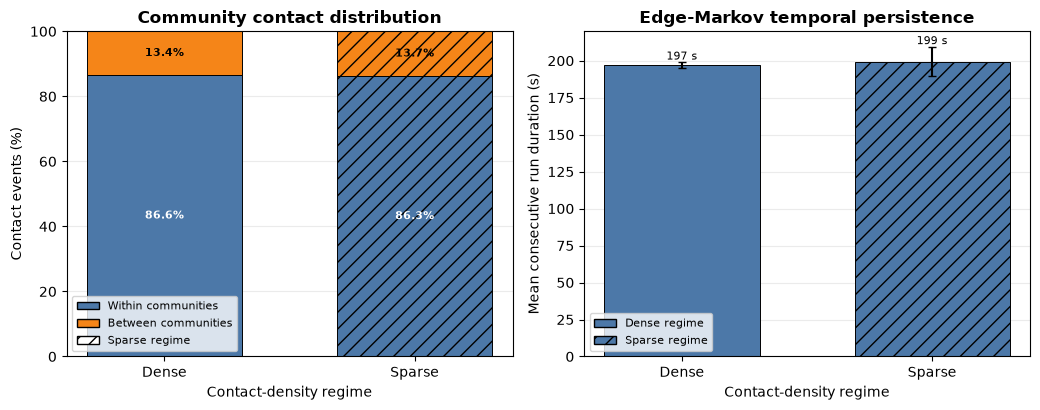

density,Dense,Sparse
seed,,
7,86.70%,86.45%
42,86.48%,85.88%
123,86.66%,86.45%


density,Dense,Sparse
seed,,
7,199.26 s,190.19 s
42,195.58 s,209.94 s
123,195.76 s,198.18 s


In [7]:
import json

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

DENSITY_ORDER = ["Dense", "Sparse"]
DENSITY_HATCHES = {"Dense": "", "Sparse": "//"}


def compute_community_contact_percentages(trace_name, trace):
    """Return intra- and inter-community contact-event percentages."""
    summary_path = MOBILITY_DIR / f"{trace_name}.summary.json"
    with summary_path.open("r", encoding="utf-8") as handle:
        summary = json.load(handle)

    community_map = summary.get("community_by_trace_node")
    if not community_map:
        raise ValueError(f"Community assignments are missing from {summary_path.name}.")

    same_community = np.asarray([
        community_map[node1] == community_map[node2]
        for node1, node2 in trace[["node1", "node2"]].itertuples(index=False, name=None)
    ])
    intra_percentage = 100 * same_community.mean()
    return intra_percentage, 100 - intra_percentage


def compute_contact_runs(trace, time_step):
    """Compute consecutive active-contact run lengths in seconds."""
    run_durations = []
    for _, pair_trace in trace.groupby(["node1", "node2"]):
        times = np.sort(pair_trace["time"].unique())
        run_breaks = np.where(np.diff(times) != time_step)[0] + 1
        for run in np.split(times, run_breaks):
            run_durations.append(len(run) * time_step)
    return np.asarray(run_durations)


structural_rows = []
for row in trace_summary.loc[trace_summary["model"] != "Real"].itertuples(index=False):
    trace = loaded_traces[row.trace]
    result = {
        "trace": row.trace,
        "model": row.model,
        "density": row.density,
        "seed": int(row.seed),
    }
    if row.model == "Community":
        intra, inter = compute_community_contact_percentages(row.trace, trace)
        result["intra_percentage"] = intra
        result["inter_percentage"] = inter
    else:
        result["mean_run_duration"] = compute_contact_runs(
            trace, int(row.time_step_s)
        ).mean()
    structural_rows.append(result)

structural_df = pd.DataFrame(structural_rows)
positions = np.arange(len(DENSITY_ORDER))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10.5, 4.2))

community_df = structural_df.loc[structural_df["model"] == "Community"].copy()
community_summary = (
    community_df.groupby("density", observed=True)[["intra_percentage", "inter_percentage"]]
    .mean()
    .reindex(DENSITY_ORDER)
)
intra_values = community_summary["intra_percentage"].to_numpy()
inter_values = community_summary["inter_percentage"].to_numpy()

ax = axes[0]
for position, density, intra, inter in zip(positions, DENSITY_ORDER, intra_values, inter_values):
    hatch = DENSITY_HATCHES[density]
    ax.bar(position, intra, width=0.62, color="#4C78A8", hatch=hatch, edgecolor="black", linewidth=0.7)
    ax.bar(position, inter, bottom=intra, width=0.62, color="#F58518", hatch=hatch, edgecolor="black", linewidth=0.7)
    ax.text(position, intra / 2, f"{intra:.1f}%", ha="center", va="center", color="white", fontsize=8, fontweight="bold")
    ax.text(position, intra + inter / 2, f"{inter:.1f}%", ha="center", va="center", fontsize=8, fontweight="bold")

ax.set_xticks(positions)
ax.set_xticklabels(DENSITY_ORDER)
ax.set_ylim(0, 100)
ax.set_xlabel("Contact-density regime")
ax.set_ylabel("Contact events (%)")
ax.set_title("Community contact distribution", fontweight="bold")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(handles=[
    Patch(facecolor="#4C78A8", edgecolor="black", label="Within communities"),
    Patch(facecolor="#F58518", edgecolor="black", label="Between communities"),
    Patch(facecolor="white", edgecolor="black", hatch="//", label="Sparse regime"),
], frameon=True, fontsize=8)

edge_df = structural_df.loc[structural_df["model"] == "Edge-Markov"].copy()
edge_summary = (
    edge_df.groupby("density", observed=True)["mean_run_duration"]
    .agg(mean="mean", std="std")
    .reindex(DENSITY_ORDER)
)
edge_values = edge_summary["mean"].to_numpy()
edge_std = edge_summary["std"].fillna(0).to_numpy()

ax = axes[1]
for position, density, value, std in zip(positions, DENSITY_ORDER, edge_values, edge_std):
    bar = ax.bar(
        position, value, yerr=std, capsize=3, width=0.62,
        color="#4C78A8", hatch=DENSITY_HATCHES[density],
        edgecolor="black", linewidth=0.7,
    )
    ax.text(bar[0].get_x() + bar[0].get_width() / 2, value + std, f"{value:.0f} s", ha="center", va="bottom", fontsize=8)

ax.set_xticks(positions)
ax.set_xticklabels(DENSITY_ORDER)
ax.set_xlabel("Contact-density regime")
ax.set_ylabel("Mean consecutive run duration (s)")
ax.set_title("Edge-Markov temporal persistence", fontweight="bold")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(handles=[
    Patch(facecolor="#4C78A8", edgecolor="black", label="Dense regime"),
    Patch(facecolor="#4C78A8", edgecolor="black", hatch="//", label="Sparse regime"),
], frameon=True, fontsize=8)

plt.tight_layout()
plt.show()

community_table = (
    community_df.pivot_table(index="seed", columns="density", values="intra_percentage")
    .reindex(columns=DENSITY_ORDER)
    .round(2)
)
edge_table = (
    edge_df.pivot_table(index="seed", columns="density", values="mean_run_duration")
    .reindex(columns=DENSITY_ORDER)
    .round(2)
)

display(community_table.style.format("{:.2f}%").set_caption("Intra-community contacts (%) by seed"))
display(edge_table.style.format("{:.2f} s").set_caption("Mean consecutive contact-run duration by seed"))


The Community model keeps approximately 86\% of contact events within communities in both density regimes. Likewise, Edge-Markov contact episodes last about 197--199 seconds in both regimes. The sparse traces therefore reduce the number of communication opportunities while preserving the community locality or temporal persistence that defines the corresponding mobility model.


### Temporal Evolution of Contact Opportunities

The following figure compares contact activity over a common 24-hour horizon. Synthetic curves are averages over three mobility seeds and are normalized by the number of possible node pairs. Colors identify the mobility model, while solid and dashed lines denote Dense and Sparse regimes, respectively.


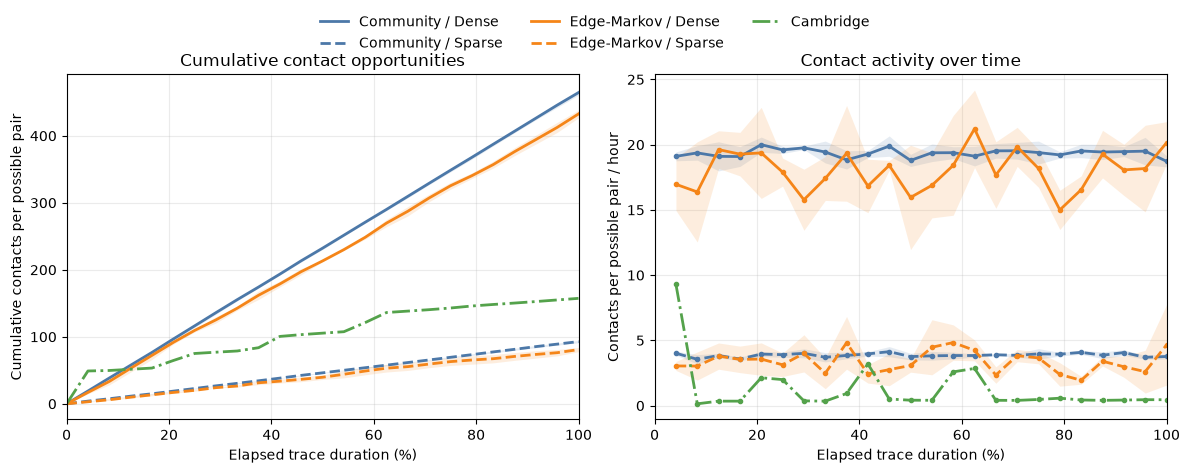

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NUM_TIME_BINS = 24
NORMALIZE_BY_PAIRS = True

SCENARIO_ORDER = [
    "Community / Dense",
    "Community / Sparse",
    "Edge-Markov / Dense",
    "Edge-Markov / Sparse",
    "Cambridge",
]

SCENARIO_COLORS = {
    "Community / Dense": "#4C78A8",
    "Community / Sparse": "#4C78A8",
    "Edge-Markov / Dense": "#F58518",
    "Edge-Markov / Sparse": "#F58518",
    "Cambridge": "#54A24B",
}

SCENARIO_LINESTYLES = {
    "Community / Dense": "-",
    "Community / Sparse": "--",
    "Edge-Markov / Dense": "-",
    "Edge-Markov / Sparse": "--",
    "Cambridge": "-.",
}


def get_scenario_label(row):
    if row.model == "Real":
        return "Cambridge"

    return f"{row.model} / {row.density}"


def compute_binned_contacts(
    trace,
    num_bins,
    normalize_by_pairs=False,
):
    """Aggregate contacts over equal relative-time intervals."""

    times = trace["time"].to_numpy(dtype=float)
    start_time = times.min()
    end_time = times.max()
    duration_seconds = end_time - start_time

    if duration_seconds <= 0:
        raise ValueError("The trace must span more than one timestamp.")

    elapsed_fraction = (times - start_time) / duration_seconds
    bin_edges = np.linspace(0, 1, num_bins + 1)

    interval_counts, _ = np.histogram(
        elapsed_fraction,
        bins=bin_edges,
    )

    num_nodes = len(set(trace["node1"]) | set(trace["node2"]))
    possible_pairs = num_nodes * (num_nodes - 1) / 2

    if normalize_by_pairs and possible_pairs > 0:
        interval_counts = interval_counts / possible_pairs

    bin_duration_hours = duration_seconds / num_bins / 3600
    interval_rate = interval_counts / bin_duration_hours

    return pd.DataFrame({
        "time_percentage": 100 * bin_edges[1:],
        "interval_contacts": interval_counts,
        "interval_rate": interval_rate,
        "cumulative_contacts": np.cumsum(interval_counts),
    })


temporal_rows = []

for row in trace_summary.itertuples(index=False):
    scenario = get_scenario_label(row)

    if scenario not in SCENARIO_ORDER:
        continue

    profile = compute_binned_contacts(
        trace=loaded_traces[row.trace],
        num_bins=NUM_TIME_BINS,
        normalize_by_pairs=NORMALIZE_BY_PAIRS,
    )

    profile["trace"] = row.trace
    profile["scenario"] = scenario
    temporal_rows.append(profile)

temporal_df = pd.concat(temporal_rows, ignore_index=True)

temporal_summary = (
    temporal_df
    .groupby(["scenario", "time_percentage"], as_index=False)
    .agg(
        cumulative_mean=("cumulative_contacts", "mean"),
        cumulative_std=("cumulative_contacts", "std"),
        rate_mean=("interval_rate", "mean"),
        rate_std=("interval_rate", "std"),
        trace_realizations=("trace", "nunique"),
    )
)

temporal_summary[["cumulative_std", "rate_std"]] = (
    temporal_summary[["cumulative_std", "rate_std"]]
    .fillna(0.0)
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 4.4),
    sharex=True,
)

for scenario in SCENARIO_ORDER:
    subset = (
        temporal_summary[
            temporal_summary["scenario"] == scenario
        ]
        .sort_values("time_percentage")
    )

    if subset.empty:
        continue

    color = SCENARIO_COLORS[scenario]
    linestyle = SCENARIO_LINESTYLES[scenario]

    time_values = np.concatenate([
        [0],
        subset["time_percentage"].to_numpy(),
    ])

    cumulative_values = np.concatenate([
        [0],
        subset["cumulative_mean"].to_numpy(),
    ])

    cumulative_std = np.concatenate([
        [0],
        subset["cumulative_std"].to_numpy(),
    ])

    axes[0].plot(
        time_values,
        cumulative_values,
        label=scenario,
        color=color,
        linestyle=linestyle,
        linewidth=2,
    )

    if subset["trace_realizations"].max() > 1:
        axes[0].fill_between(
            time_values,
            cumulative_values - cumulative_std,
            cumulative_values + cumulative_std,
            color=color,
            alpha=0.14,
            linewidth=0,
        )

    rate_mean = subset["rate_mean"].to_numpy()
    rate_std = subset["rate_std"].to_numpy()

    axes[1].plot(
        subset["time_percentage"],
        rate_mean,
        label=scenario,
        color=color,
        linestyle=linestyle,
        linewidth=2,
        marker="o",
        markersize=3,
    )

    if subset["trace_realizations"].max() > 1:
        axes[1].fill_between(
            subset["time_percentage"],
            np.maximum(rate_mean - rate_std, 0),
            rate_mean + rate_std,
            color=color,
            alpha=0.14,
            linewidth=0,
        )

if NORMALIZE_BY_PAIRS:
    cumulative_ylabel = "Cumulative contacts per possible pair"
    rate_ylabel = "Contacts per possible pair / hour"
else:
    cumulative_ylabel = "Cumulative contact events"
    rate_ylabel = "Contact events / hour"

axes[0].set_title("Cumulative contact opportunities")
axes[0].set_xlabel("Elapsed trace duration (%)")
axes[0].set_ylabel(cumulative_ylabel)

axes[1].set_title("Contact activity over time")
axes[1].set_xlabel("Elapsed trace duration (%)")
axes[1].set_ylabel(rate_ylabel)

for ax in axes:
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.grid(True, alpha=0.25)
    ax.set_axisbelow(True)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.08),
    frameon=False,
)

plt.tight_layout()
plt.show()

Dense synthetic traces sustain approximately 18--20 contacts per possible pair per hour, whereas Sparse traces sustain roughly 3--4. Consequently, cumulative opportunity exposure after 24 hours is about five times lower in the sparse regime. Within the same density regime, the Community and Edge-Markov curves remain comparable in aggregate rate; their difference lies in the community structure and contact persistence characterized above.

Cambridge displays a distinct bursty pattern: activity is high at the beginning of the trace, then drops sharply for much of the 24-hour window. It therefore complements the controlled synthetic regimes with a realistic, temporally uneven contact process.


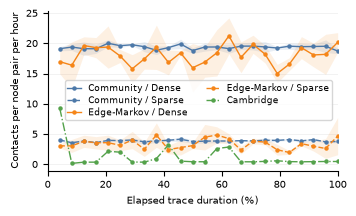

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OUTPUT_DIR = Path("./plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGSIZE = (3.45, 2.05)
NUM_TIME_BINS = 24

SCENARIO_ORDER = [
    "Community / Dense",
    "Community / Sparse",
    "Edge-Markov / Dense",
    "Edge-Markov / Sparse",
    "Cambridge",
]

SCENARIO_COLORS = {
    "Community / Dense": "#4C78A8",
    "Community / Sparse": "#4C78A8",
    "Edge-Markov / Dense": "#F58518",
    "Edge-Markov / Sparse": "#F58518",
    "Cambridge": "#54A24B",
}

SCENARIO_LINESTYLES = {
    "Community / Dense": "-",
    "Community / Sparse": "--",
    "Edge-Markov / Dense": "-",
    "Edge-Markov / Sparse": "--",
    "Cambridge": "-.",
}


def get_scenario_label(row):
    """Return the display label of a supported contact-trace scenario."""
    if row.model == "Real":
        return "Cambridge"

    return f"{row.model} / {row.density}"


def compute_relative_contact_rate(trace, num_bins):
    """
    Compute contact rates over equal relative-time intervals.

    The x-axis is normalized to the 0--100% duration of each trace.
    Values are normalized by the number of possible node pairs and by
    the actual duration of each temporal bin.
    """
    times = trace["time"].to_numpy(dtype=float)

    start_time = times.min()
    end_time = times.max()
    duration_seconds = end_time - start_time

    if duration_seconds <= 0:
        raise ValueError("The trace must span more than one timestamp.")

    num_nodes = len(set(trace["node1"]) | set(trace["node2"]))
    possible_pairs = num_nodes * (num_nodes - 1) / 2

    if possible_pairs <= 0:
        raise ValueError("The trace must contain at least two nodes.")

    elapsed_fraction = (times - start_time) / duration_seconds
    bin_edges = np.linspace(0, 1, num_bins + 1)

    contact_counts, _ = np.histogram(
        elapsed_fraction,
        bins=bin_edges,
    )

    bin_duration_hours = duration_seconds / num_bins / 3600

    contact_rate = (
        contact_counts
        / possible_pairs
        / bin_duration_hours
    )

    return pd.DataFrame({
        "elapsed_percentage": 100 * bin_edges[1:],
        "contacts_per_pair_per_hour": contact_rate,
    })


# Compute one profile for every trace realization.
temporal_rows = []

for row in trace_summary.itertuples(index=False):
    scenario = get_scenario_label(row)

    if scenario not in SCENARIO_ORDER:
        continue

    profile = compute_relative_contact_rate(
        trace=loaded_traces[row.trace],
        num_bins=NUM_TIME_BINS,
    )

    profile["scenario"] = scenario
    profile["trace"] = row.trace
    temporal_rows.append(profile)

if not temporal_rows:
    raise RuntimeError("No compatible contact traces were found.")

temporal_df = pd.concat(
    temporal_rows,
    ignore_index=True,
)

# Average the synthetic trace realizations generated with different seeds.
temporal_summary = (
    temporal_df
    .groupby(
        ["scenario", "elapsed_percentage"],
        as_index=False,
    )
    .agg(
        mean_rate=(
            "contacts_per_pair_per_hour",
            "mean",
        ),
        std_rate=(
            "contacts_per_pair_per_hour",
            "std",
        ),
        trace_realizations=("trace", "nunique"),
    )
)

temporal_summary["std_rate"] = (
    temporal_summary["std_rate"]
    .fillna(0.0)
)

# Generate the paper figure.
fig, ax = plt.subplots(
    figsize=FIGSIZE,
    constrained_layout=True,
)

for scenario in SCENARIO_ORDER:
    subset = (
        temporal_summary[
            temporal_summary["scenario"] == scenario
        ]
        .sort_values("elapsed_percentage")
    )

    if subset.empty:
        print(f"Skipping unavailable scenario: {scenario}")
        continue

    x_values = subset["elapsed_percentage"].to_numpy()
    mean_values = subset["mean_rate"].to_numpy()
    std_values = subset["std_rate"].to_numpy()

    ax.plot(
        x_values,
        mean_values,
        label=scenario,
        color=SCENARIO_COLORS[scenario],
        linestyle=SCENARIO_LINESTYLES[scenario],
        linewidth=1,
        marker="o",
        markersize=2.2,
    )

    if subset["trace_realizations"].max() > 1:
        ax.fill_between(
            x_values,
            np.maximum(mean_values - std_values, 0),
            mean_values + std_values,
            color=SCENARIO_COLORS[scenario],
            alpha=0.12,
            linewidth=0,
        )

ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 20))
ax.set_xlabel("Elapsed trace duration (%)", fontsize=7)
ax.set_ylabel("Contacts per node pair per hour", fontsize=7)

ax.tick_params(
    axis="both",
    labelsize=7,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.grid(
    axis="y",
    alpha=0.22,
    linewidth=0.5,
)
ax.set_axisbelow(True)

ax.legend(
    loc="center",
    bbox_to_anchor=(0.52, 0.44),
    fontsize=6.5,
    frameon=True,
    handlelength=1.5,
    borderpad=0.3,
    labelspacing=0.22,
    ncol=2
)

fig.savefig(
    OUTPUT_DIR / "contact_temporal_activity.pdf",
    bbox_inches="tight",
)

plt.show()

# Simulation Results

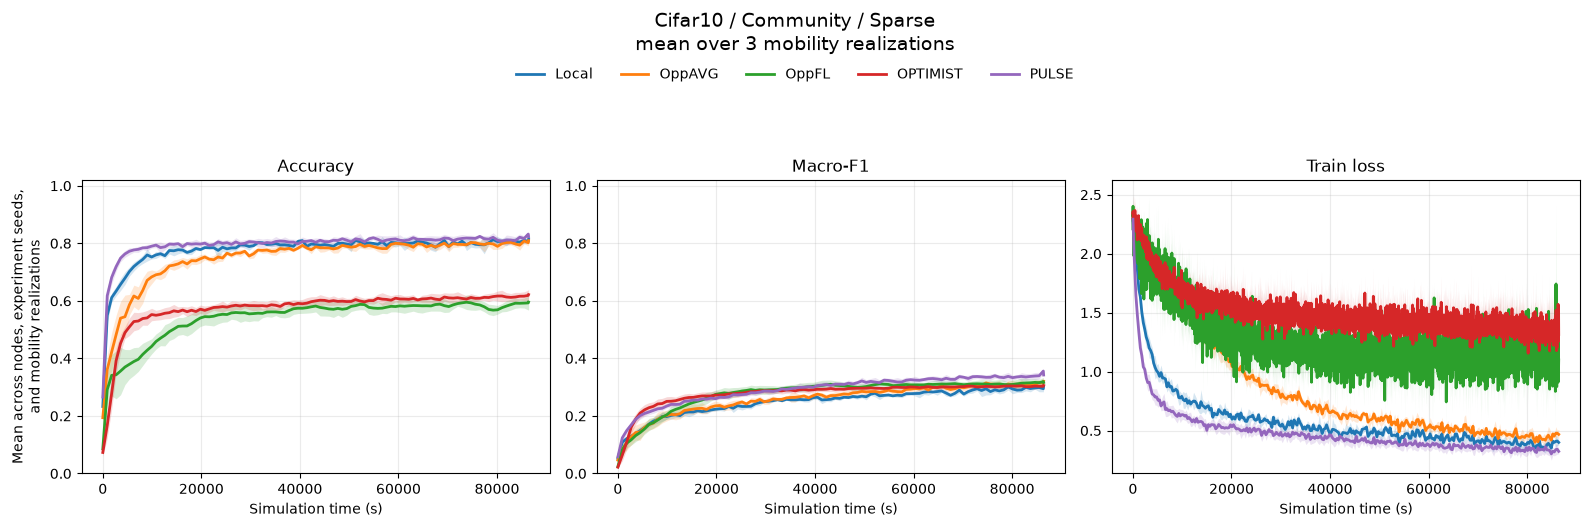

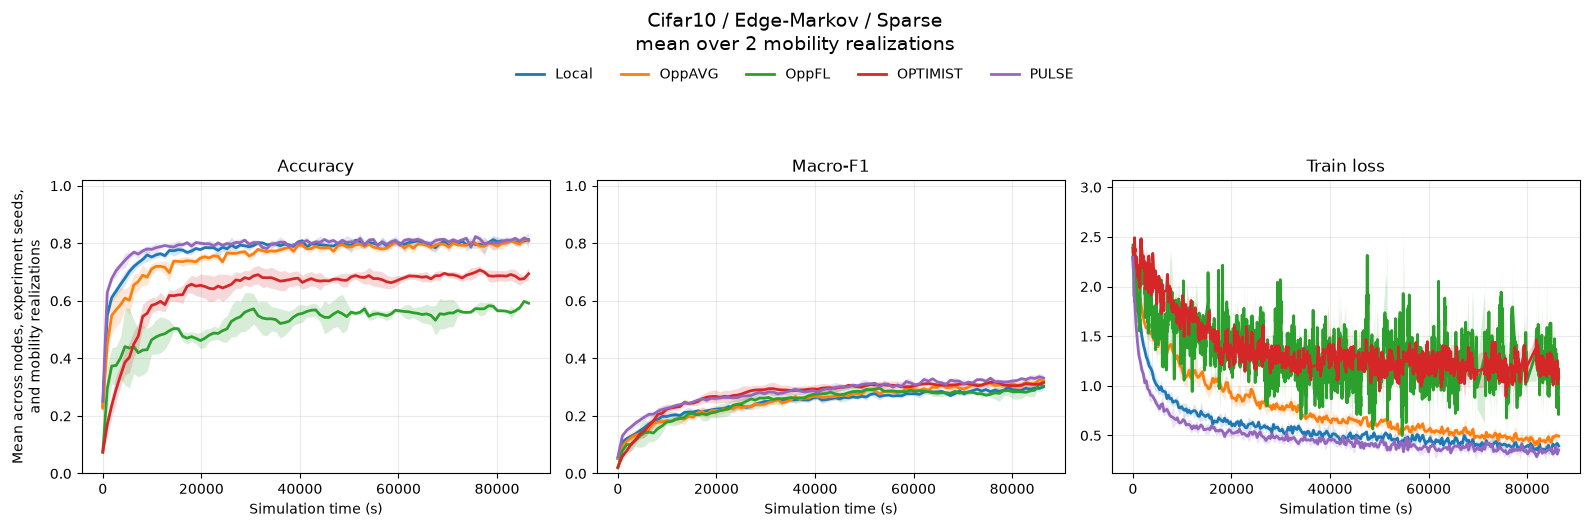

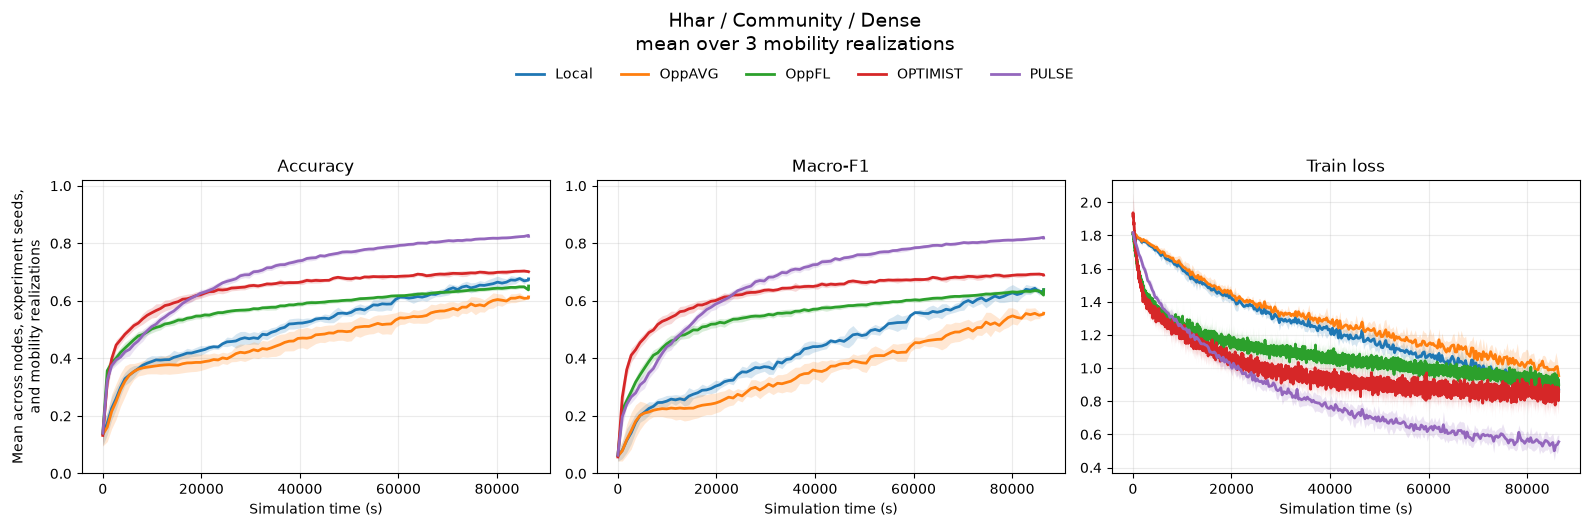

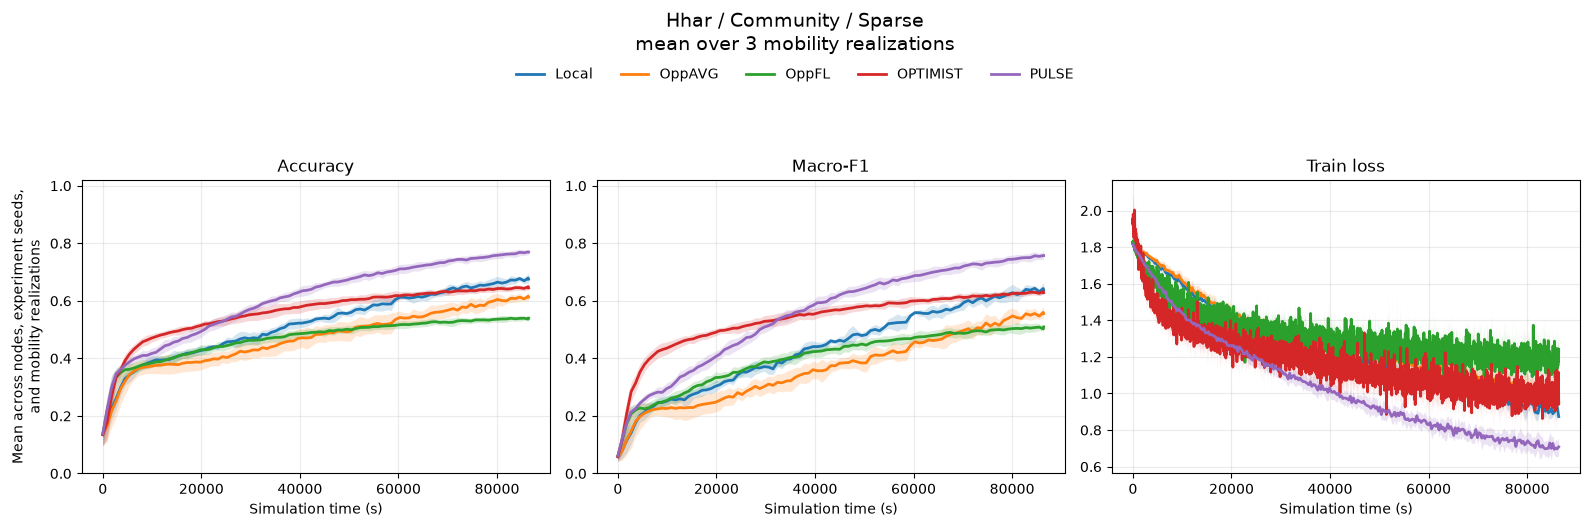

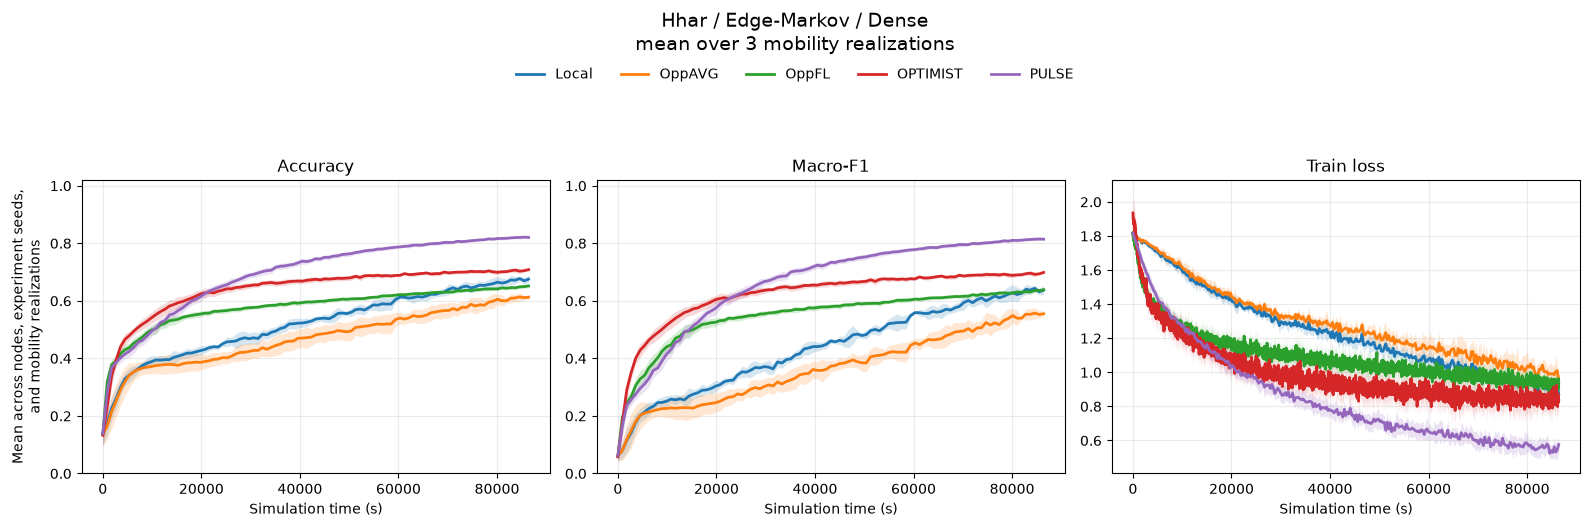

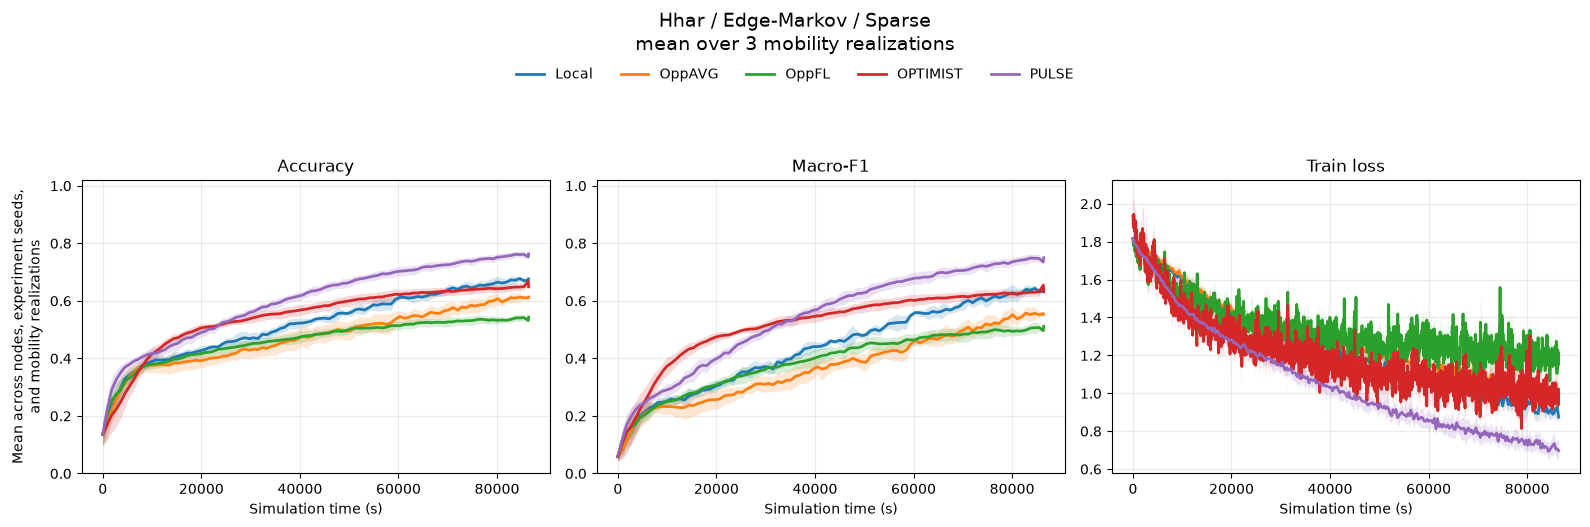

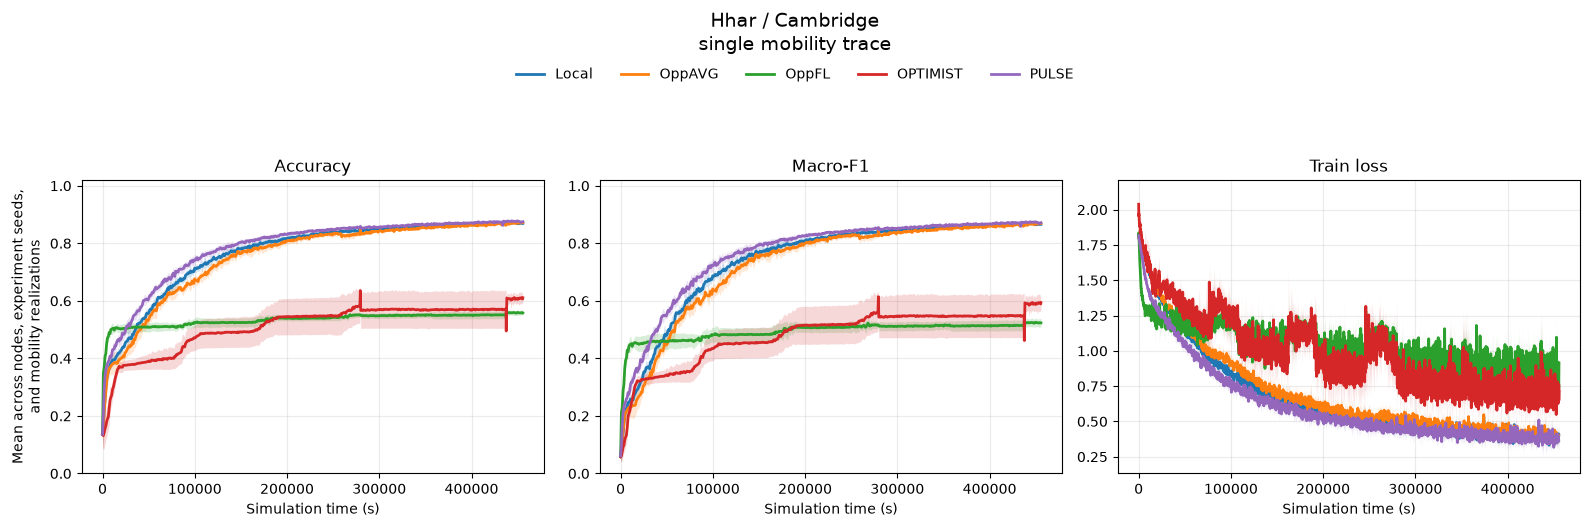

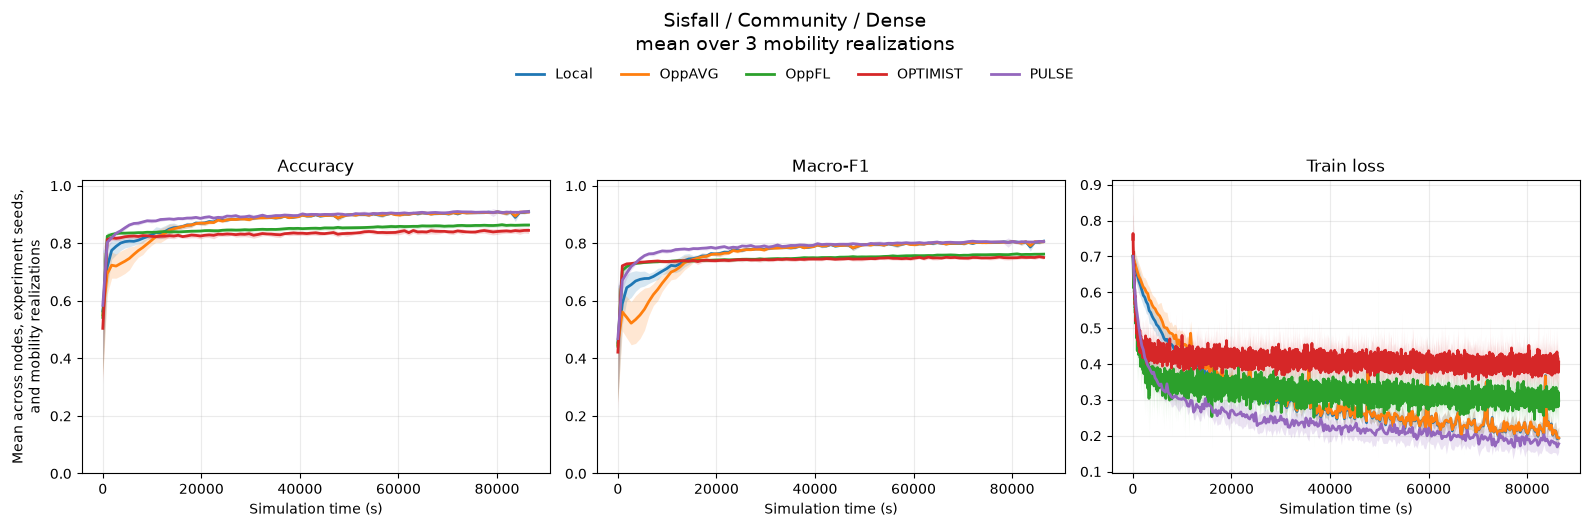

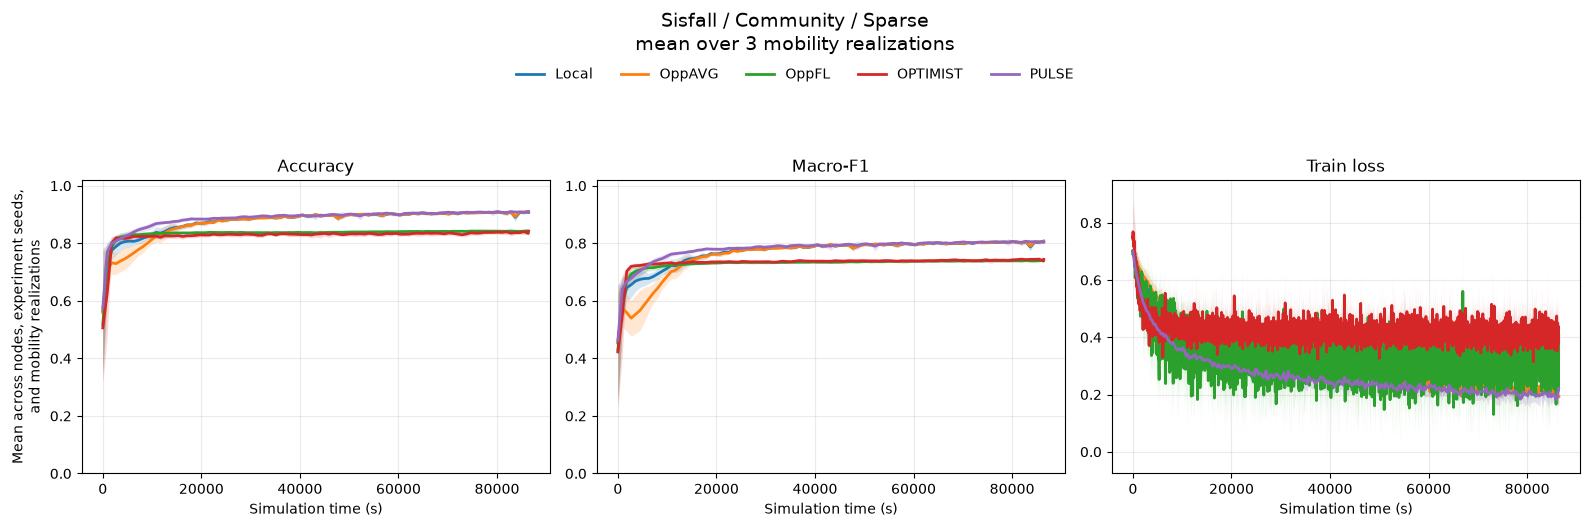

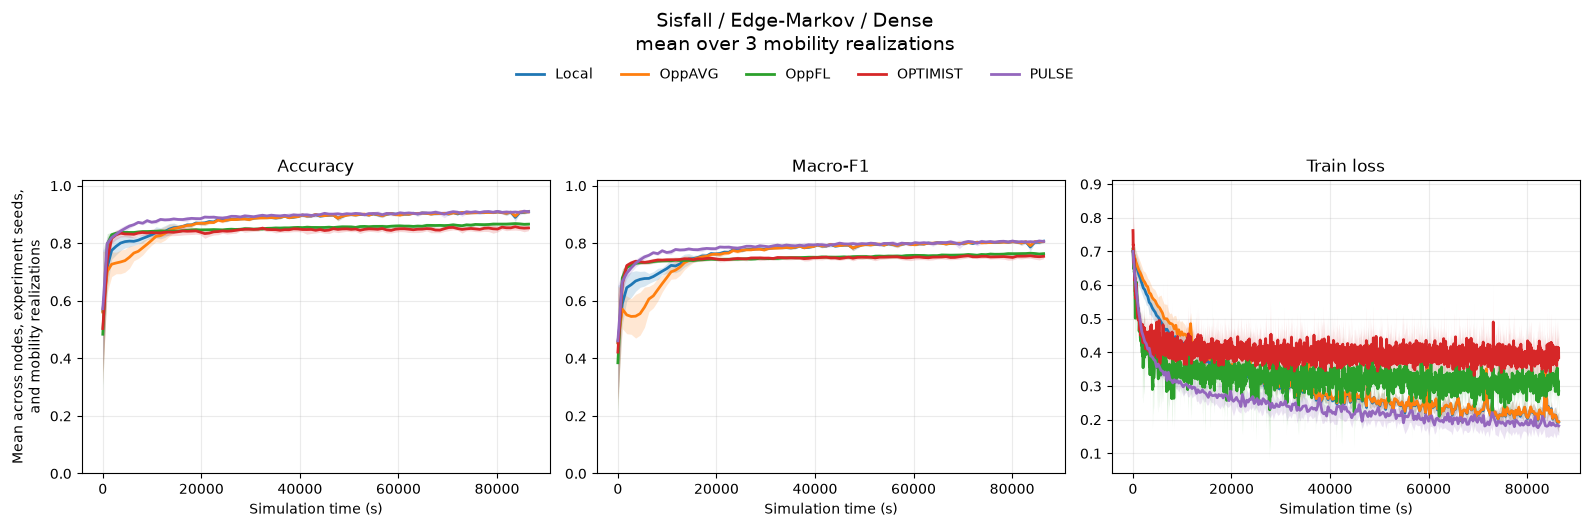

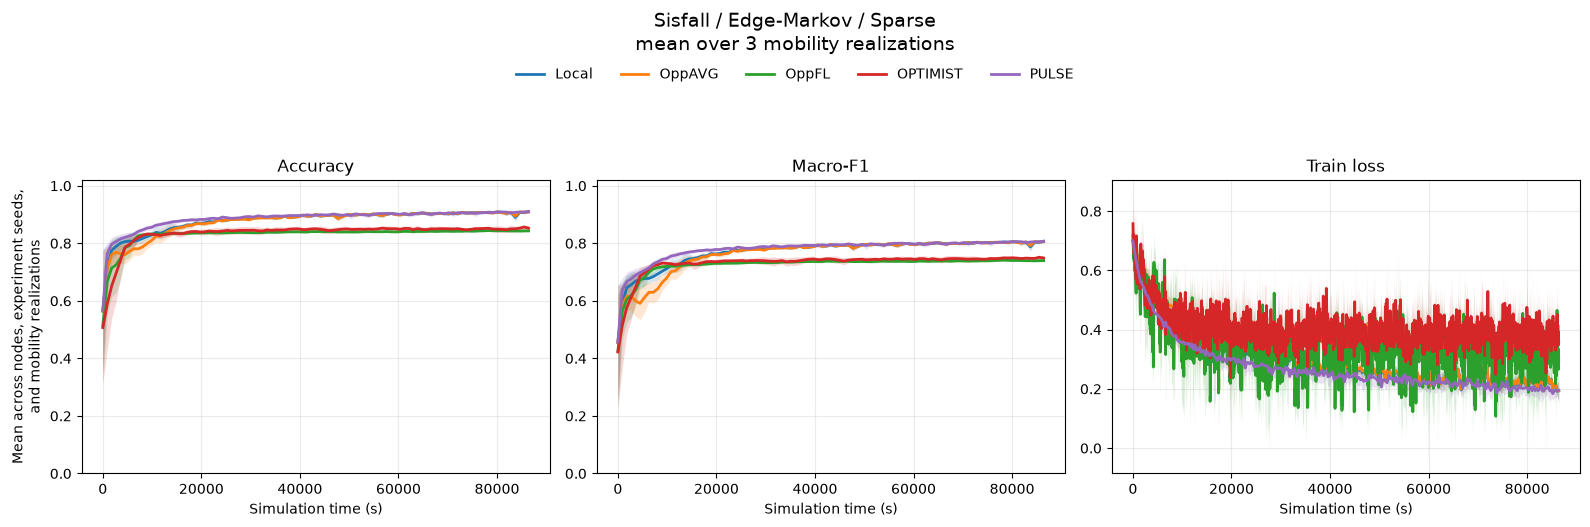

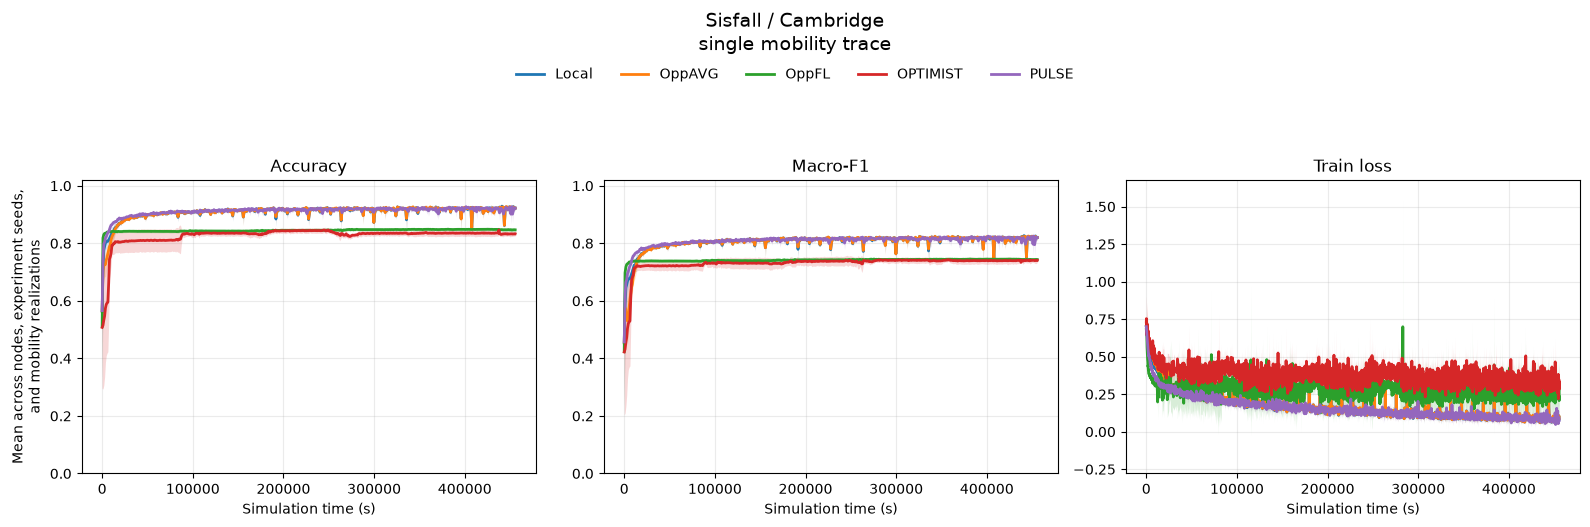

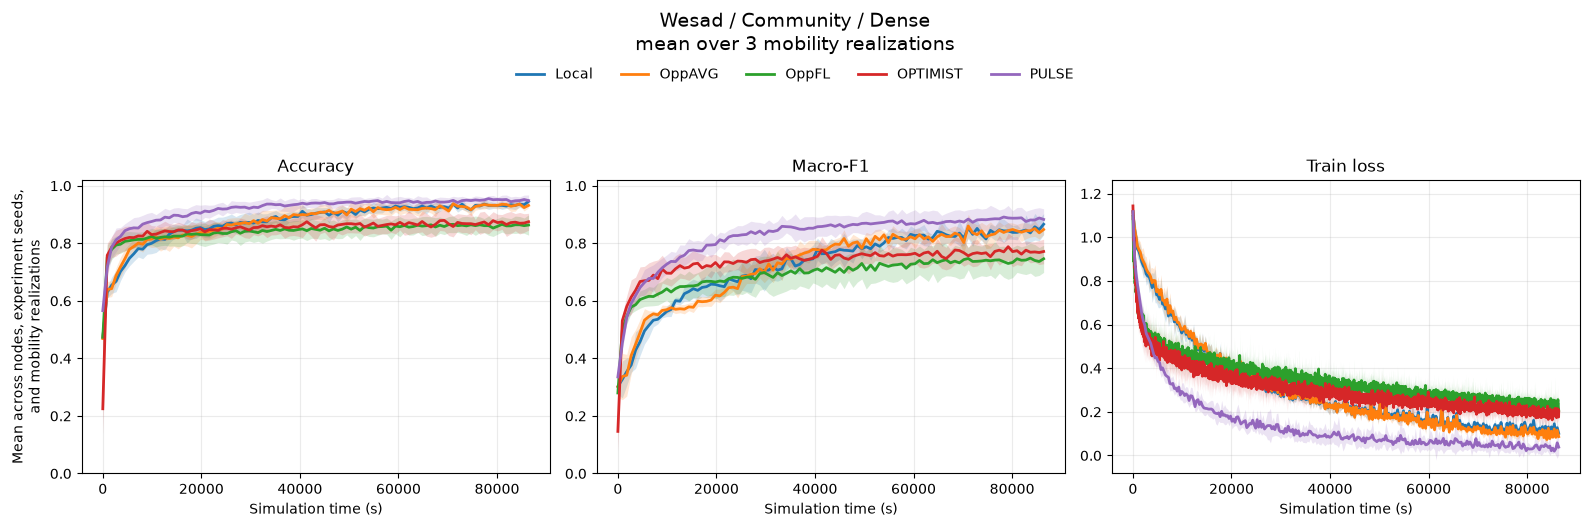

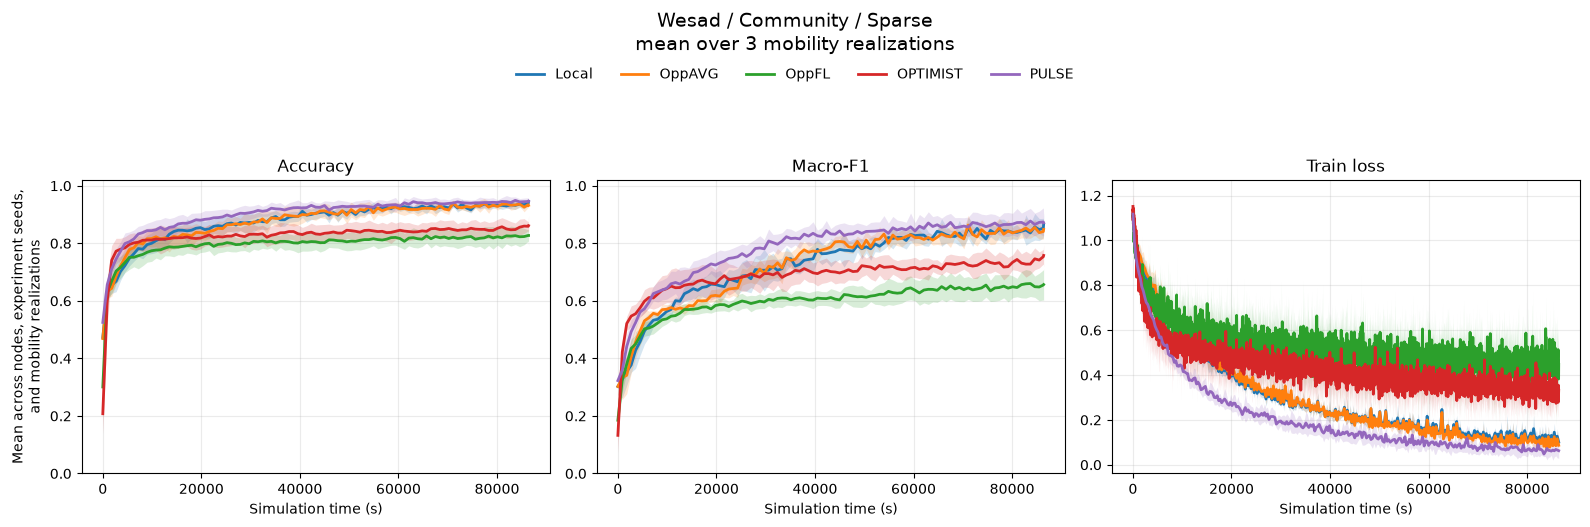

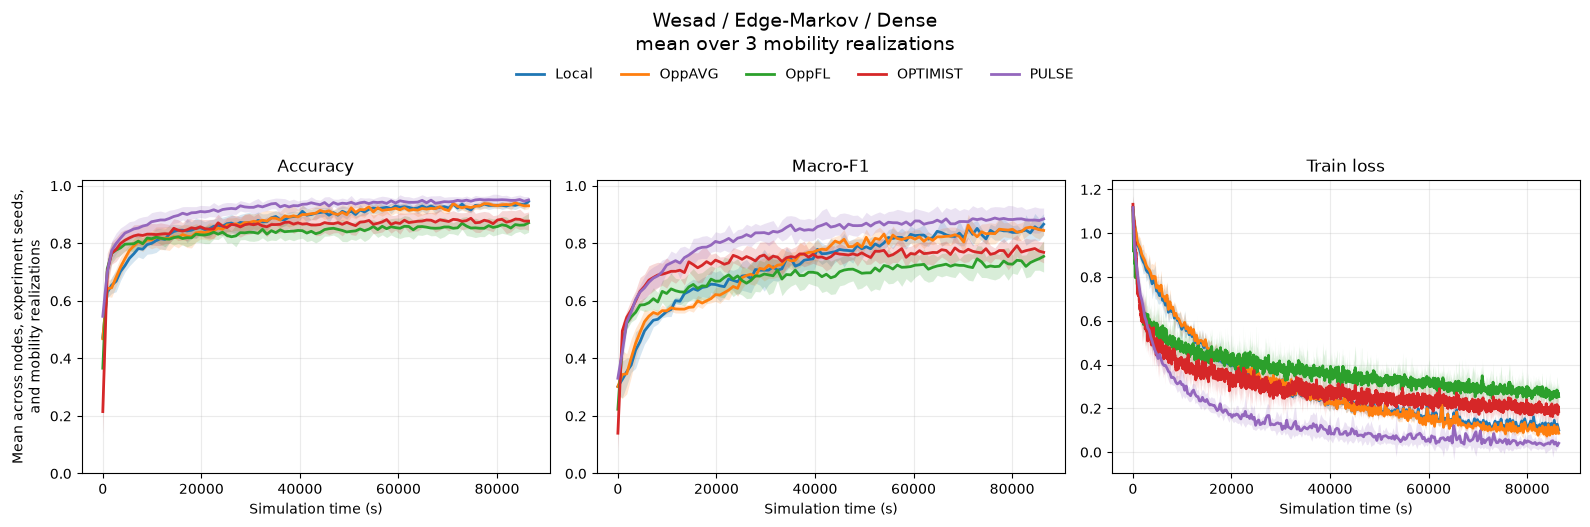

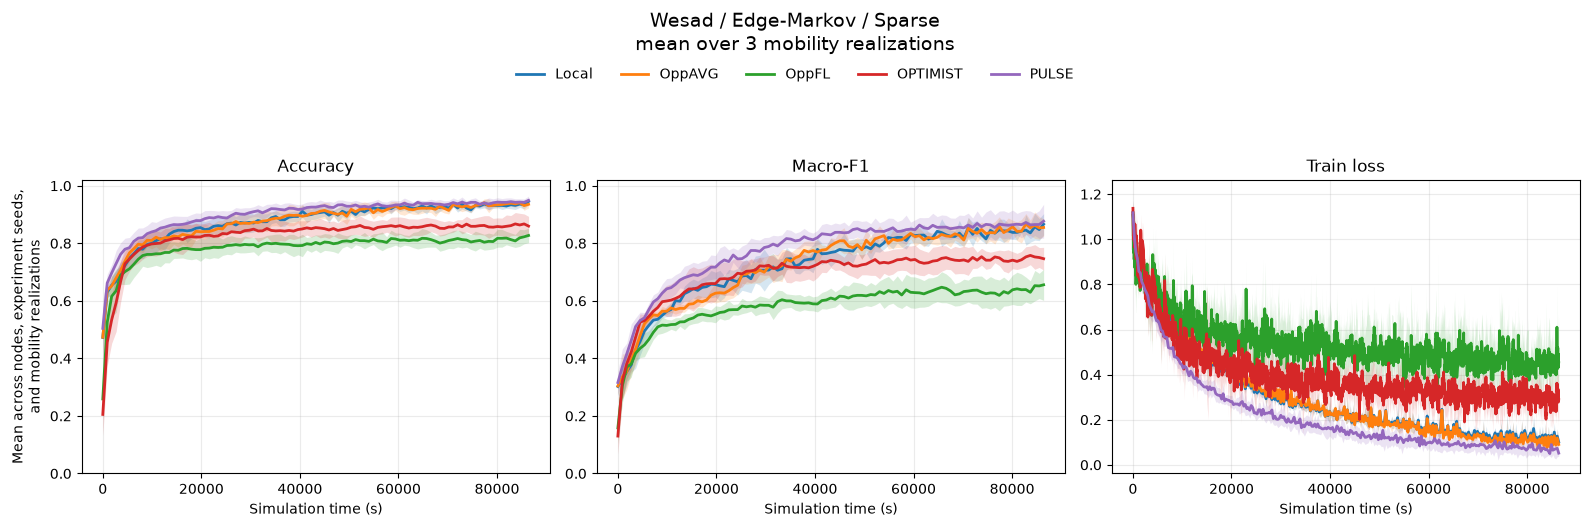

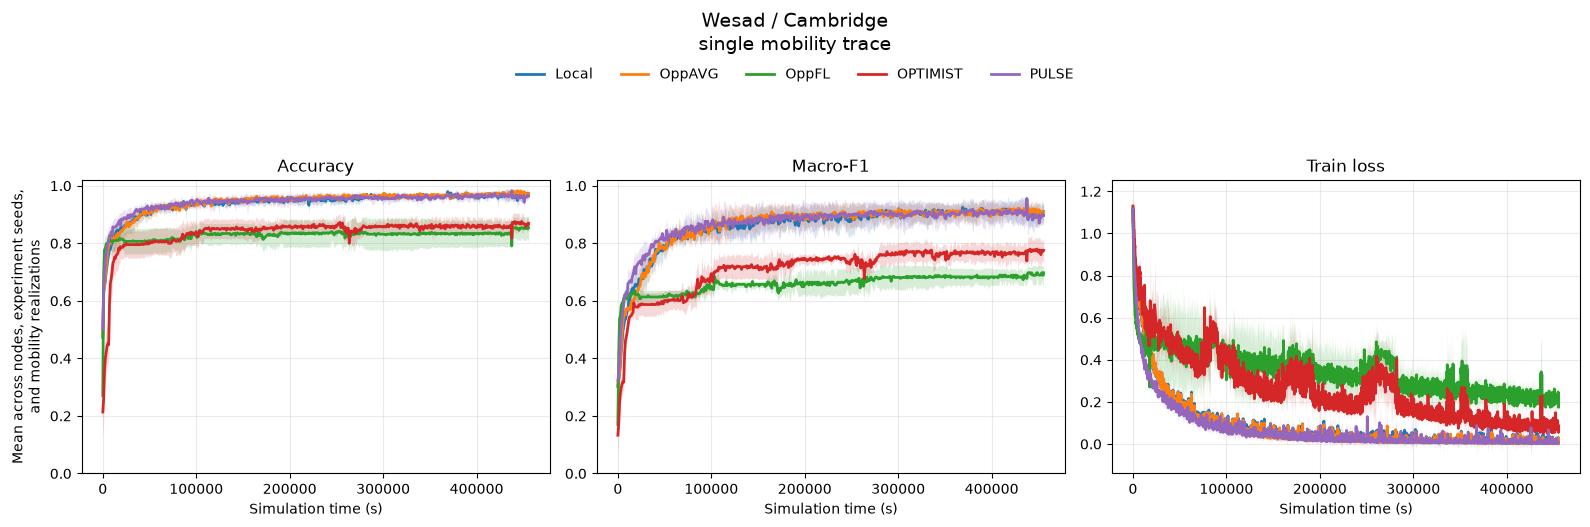

In [ ]:
from itertools import cycle
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS_ROOT = Path("./results")

ALGORITHM_ORDER = [
    "local",
    "oppavg",
    "oppfl",
    "optimist",
    "pulse",
]

ALGORITHM_LABELS = {
    "local": "Local",
    "oppavg": "OppAVG",
    "oppfl": "OppFL",
    "optimist": "OPTIMIST",
    "pulse": "PULSE",
}

METRICS = {
    "accuracy": ("Accuracy", "metrics.csv"),
    "macro_f1": ("Macro-F1", "metrics.csv"),
    "loss": ("Train loss", "training.csv"),
}

MOBILITY_LABELS = {
    "community_dense": "Community / Dense",
    "community_sparse": "Community / Sparse",
    "edge_markov_dense": "Edge-Markov / Dense",
    "edge_markov_sparse": "Edge-Markov / Sparse",
    "cambridge": "Cambridge",
}

MOBILITY_ORDER = list(MOBILITY_LABELS)

MOBILITY_SEED_PATTERN = re.compile(
    r"^(?P<scenario>(?:community|edge_markov)_(?:dense|sparse))"
    r"_seed(?P<seed>\d+)$"
)


def parse_mobility_name(directory_name):
    """Return a supported mobility scenario and its optional trace seed."""
    if directory_name == "cambridge":
        return "cambridge", None

    match = MOBILITY_SEED_PATTERN.fullmatch(directory_name)

    if match:
        return (
            match.group("scenario"),
            int(match.group("seed")),
        )

    return None, None


def load_metric_file(data_path, metric, mobility_seed):
    """Load one metric file and average the metric across nodes."""
    df = pd.read_csv(data_path)

    if metric not in df.columns:
        return pd.DataFrame()

    required_columns = {"seed", "time"}
    missing_columns = required_columns - set(df.columns)

    if missing_columns:
        raise ValueError(
            f"{data_path} is missing columns: {sorted(missing_columns)}"
        )

    if data_path.name == "metrics.csv":
        if "split" not in df.columns:
            raise ValueError(
                f"{data_path} does not contain the 'split' column."
            )

        df = df[df["split"] == "test"].copy()

    if df.empty:
        return pd.DataFrame()

    # Collapse the node dimension while preserving experimental seeds.
    per_run = (
        df
        .groupby(["seed", "time"], as_index=False)[metric]
        .mean()
        .rename(columns={"seed": "experiment_seed"})
    )

    per_run["mobility_seed"] = mobility_seed

    return per_run


result_records = []

for dataset_dir in sorted(RESULTS_ROOT.iterdir()):
    if not dataset_dir.is_dir():
        continue

    dataset = dataset_dir.name

    for mobility_dir in sorted(dataset_dir.iterdir()):
        if not mobility_dir.is_dir():
            continue

        mobility, mobility_seed = parse_mobility_name(
            mobility_dir.name
        )

        if mobility is None:
            print(
                f"Ignoring legacy or unsupported result directory: "
                f"{mobility_dir}"
            )
            continue

        for algorithm in ALGORITHM_ORDER:
            algorithm_dir = mobility_dir / algorithm

            if not algorithm_dir.is_dir():
                continue

            for metric, (_, filename) in METRICS.items():
                data_path = algorithm_dir / filename

                if not data_path.exists():
                    continue

                per_run = load_metric_file(
                    data_path=data_path,
                    metric=metric,
                    mobility_seed=mobility_seed,
                )

                if per_run.empty:
                    continue

                per_run["dataset"] = dataset
                per_run["mobility"] = mobility
                per_run["algorithm"] = algorithm
                per_run["metric"] = metric

                result_records.append(per_run)

if not result_records:
    raise FileNotFoundError(
        f"No valid experiment results were found under "
        f"{RESULTS_ROOT.resolve()}."
    )

results_df = pd.concat(result_records, ignore_index=True)

# Cambridge is one real-trace realization; synthetic scenarios have three seeds.
results_df["mobility_seed"] = (
    results_df["mobility_seed"]
    .astype("Int64")
    .astype("string")
    .fillna("real")
)

results_df["mobility"] = pd.Categorical(
    results_df["mobility"],
    categories=MOBILITY_ORDER,
    ordered=True,
)

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

algorithm_colors = {
    algorithm: color
    for algorithm, color in zip(
        ALGORITHM_ORDER,
        cycle(default_colors),
    )
}

figure_groups = (
    results_df[["dataset", "mobility"]]
    .drop_duplicates()
    .sort_values(["dataset", "mobility"])
)

for group in figure_groups.itertuples(index=False):
    dataset = group.dataset
    mobility = group.mobility

    figure_df = results_df[
        (results_df["dataset"] == dataset)
        & (results_df["mobility"] == mobility)
    ].copy()

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(METRICS),
        figsize=(16, 4.5),
        sharex=True,
    )

    plotted_algorithms = []

    for algorithm in ALGORITHM_ORDER:
        algorithm_df = figure_df[
            figure_df["algorithm"] == algorithm
        ]

        if algorithm_df.empty:
            continue

        algorithm_plotted = False

        for ax, (metric, (title, _)) in zip(
            axes,
            METRICS.items(),
        ):
            metric_df = algorithm_df[
                algorithm_df["metric"] == metric
            ]

            if metric_df.empty:
                continue

            summary = (
                metric_df
                .groupby("time")[metric]
                .agg(
                    mean="mean",
                    std="std",
                    runs="size",
                )
                .reset_index()
                .sort_values("time")
            )

            summary["std"] = summary["std"].fillna(0.0)
            color = algorithm_colors[algorithm]

            ax.plot(
                summary["time"],
                summary["mean"],
                label=ALGORITHM_LABELS[algorithm],
                color=color,
                linewidth=2,
            )

            ax.fill_between(
                summary["time"],
                summary["mean"] - summary["std"],
                summary["mean"] + summary["std"],
                color=color,
                alpha=0.18,
                linewidth=0,
            )

            ax.set_title(title)
            ax.set_xlabel("Simulation time (s)")
            ax.grid(True, alpha=0.25)
            ax.set_axisbelow(True)

            algorithm_plotted = True

        if algorithm_plotted:
            plotted_algorithms.append(algorithm)

    axes[0].set_ylabel(
        "Mean across nodes, experiment seeds,\n"
        "and mobility realizations"
    )
    axes[0].set_ylim(0, 1.02)
    axes[1].set_ylim(0, 1.02)

    legend_handles = [
        plt.Line2D(
            [0],
            [0],
            color=algorithm_colors[algorithm],
            linewidth=2,
            label=ALGORITHM_LABELS[algorithm],
        )
        for algorithm in plotted_algorithms
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=max(1, len(legend_handles)),
        bbox_to_anchor=(0.5, 1.06),
        frameon=False,
    )

    mobility_seed_count = figure_df["mobility_seed"].nunique()

    if mobility_seed_count > 1:
        seed_note = (
            f"mean over {mobility_seed_count} mobility realizations"
        )
    else:
        seed_note = "single mobility trace"

    fig.suptitle(
        f"{dataset.replace('_', ' ').title()} / "
        f"{MOBILITY_LABELS[str(mobility)]}\n"
        f"{seed_note}",
        y=1.16,
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

### Classification Results (Table)

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd

# This cell expects `results_df` to have been created by the result-loading cell.

TABLE_DATASETS = [
    "hhar",
    "sisfall",
    "wesad",
]

TABLE_ALGORITHMS = [
    "local",
    "oppavg",
    "oppfl",
    "optimist",
    "pulse",
]

TABLE_SCENARIOS = [
    "cambridge",
    "community_dense",
    "community_sparse",
    "edge_markov_dense",
    "edge_markov_sparse",
]

TABLE_METRICS = [
    "accuracy",
    "macro_f1",
    "loss",
]

DATASET_LABELS = {
    "hhar": "HHAR",
    "sisfall": "SisFall",
    "wesad": "WESAD",
}

ALGORITHM_LABELS = {
    "local": "Local",
    "oppavg": "OppAVG",
    "oppfl": "OppFL",
    "optimist": "OPTIMIST",
    "pulse": "PULSE",
}

SCENARIO_LABELS = {
    "cambridge": "Cambridge",
    "community_dense": "Community\nDense",
    "community_sparse": "Community\nSparse",
    "edge_markov_dense": "Edge-Markov\nDense",
    "edge_markov_sparse": "Edge-Markov\nSparse",
}

METRIC_LABELS = {
    "accuracy": "Acc.",
    "macro_f1": "F1",
    "loss": "Loss",
}

OUTPUT_DIR = Path("./plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = OUTPUT_DIR / "final_results_table.csv"
SUMMARY_CSV_PATH = OUTPUT_DIR / "final_results_summary.csv"

if "results_df" not in globals():
    raise RuntimeError(
        "Run the result-loading cell first to create `results_df`."
    )

# Store each metric in a common numeric column.
metric_frames = []

for metric in TABLE_METRICS:
    metric_frame = results_df[
        results_df["metric"].eq(metric)
    ].copy()

    if metric_frame.empty:
        continue

    if metric not in metric_frame.columns:
        raise ValueError(
            f"Column '{metric}' is missing from results_df."
        )

    metric_frame["value"] = metric_frame[metric]
    metric_frames.append(metric_frame)

if not metric_frames:
    raise RuntimeError("No compatible results are available.")

table_results = pd.concat(
    metric_frames,
    ignore_index=True,
)

# Select the final evaluation point independently for each run.
run_columns = [
    "dataset",
    "mobility",
    "algorithm",
    "metric",
    "experiment_seed",
    "mobility_seed",
]

final_results = (
    table_results
    .loc[
        table_results
        .groupby(run_columns, observed=True)["time"]
        .idxmax()
    ]
    .copy()
)

# Aggregate over experimental seeds and synthetic mobility realizations.
summary_df = (
    final_results
    .groupby(
        ["dataset", "mobility", "algorithm", "metric"],
        observed=True,
    )
    .agg(
        mean=("value", "mean"),
        std=("value", "std"),
        runs=("value", "size"),
    )
    .reset_index()
)

summary_df["std"] = summary_df["std"].fillna(0.0)

# Export a numeric, long-format table for later analysis.
summary_df.to_csv(
    SUMMARY_CSV_PATH,
    index=False,
)

# Add every expected dataset × algorithm × scenario × metric combination,
# so unavailable experiments are explicitly represented as "-".
full_index = pd.MultiIndex.from_product(
    [
        TABLE_DATASETS,
        TABLE_ALGORITHMS,
        TABLE_SCENARIOS,
        TABLE_METRICS,
    ],
    names=[
        "dataset",
        "algorithm",
        "mobility",
        "metric",
    ],
)

complete_summary = (
    summary_df
    .set_index(
        ["dataset", "algorithm", "mobility", "metric"]
    )
    .reindex(full_index)
    .reset_index()
)

table_index = pd.MultiIndex.from_product(
    [TABLE_DATASETS, TABLE_ALGORITHMS],
    names=["dataset", "algorithm"],
)

table_columns = pd.MultiIndex.from_product(
    [TABLE_SCENARIOS, TABLE_METRICS],
    names=["Scenario", "Metric"],
)

mean_table = (
    complete_summary
    .pivot(
        index=["dataset", "algorithm"],
        columns=["mobility", "metric"],
        values="mean",
    )
    .reindex(
        index=table_index,
        columns=table_columns,
    )
)

std_table = (
    complete_summary
    .pivot(
        index=["dataset", "algorithm"],
        columns=["mobility", "metric"],
        values="std",
    )
    .reindex(
        index=table_index,
        columns=table_columns,
    )
)

runs_table = (
    complete_summary
    .pivot(
        index=["dataset", "algorithm"],
        columns=["mobility", "metric"],
        values="runs",
    )
    .reindex(
        index=table_index,
        columns=table_columns,
    )
)

# Format the displayed and exported paper table.
formatted_table = mean_table.copy().astype(object)

for row_index in table_index:
    for scenario in TABLE_SCENARIOS:
        for metric in TABLE_METRICS:
            column = (scenario, metric)

            mean_value = mean_table.loc[row_index, column]
            std_value = std_table.loc[row_index, column]
            num_runs = runs_table.loc[row_index, column]

            if pd.isna(mean_value):
                formatted_table.loc[row_index, column] = "-"

            elif metric in {"accuracy", "macro_f1"}:
                formatted_table.loc[row_index, column] = (
                    f"{100 * mean_value:.1f} "
                    f"± {100 * std_value:.1f}"
                )

            else:
                formatted_table.loc[row_index, column] = (
                    f"{mean_value:.3f} "
                    f"± {std_value:.3f}"
                )

# Best values are based on the mean:
# maximum for Accuracy and Macro-F1, minimum for Loss.
best_mask = pd.DataFrame(
    False,
    index=table_index,
    columns=table_columns,
)

for dataset in TABLE_DATASETS:
    dataset_values = mean_table.xs(
        dataset,
        level="dataset",
    )

    for scenario in TABLE_SCENARIOS:
        for metric in TABLE_METRICS:
            column = (scenario, metric)
            values = dataset_values[column].dropna()

            if values.empty:
                continue

            best_value = (
                values.min()
                if metric == "loss"
                else values.max()
            )

            for algorithm in values.index[
                np.isclose(values, best_value)
            ]:
                best_mask.loc[
                    (dataset, algorithm),
                    column,
                ] = True

# Replace internal identifiers with paper labels.
formatted_table.index = pd.MultiIndex.from_tuples(
    [
        (
            DATASET_LABELS[dataset],
            ALGORITHM_LABELS[algorithm],
        )
        for dataset, algorithm in formatted_table.index
    ],
    names=["Dataset", "Method"],
)

formatted_table.columns = pd.MultiIndex.from_tuples(
    [
        (
            SCENARIO_LABELS[scenario],
            METRIC_LABELS[metric],
        )
        for scenario, metric in formatted_table.columns
    ],
    names=["Scenario", "Metric"],
)

best_mask.index = formatted_table.index
best_mask.columns = formatted_table.columns

# Export the same formatted table shown in the notebook.
formatted_table.to_csv(CSV_PATH)

table_styles = pd.DataFrame(
    "",
    index=formatted_table.index,
    columns=formatted_table.columns,
)

table_styles[best_mask] = "font-weight: bold;"

display(
    formatted_table.style
    .apply(lambda _: table_styles, axis=None)
    .set_caption(
        "Final test performance: mean ± standard deviation "
        "over all available experimental and mobility-trace realizations. "
        "Accuracy and Macro-F1 are percentages; Loss is unscaled. "
        "Bold indicates the best mean value."
    )
    .set_properties(
        **{
            "text-align": "center",
            "white-space": "nowrap",
        }
    )
)

print(f"Formatted table saved to: {CSV_PATH.resolve()}")
print(f"Numeric summary saved to: {SUMMARY_CSV_PATH.resolve()}")

Formatted table saved to: /var/home/mattia/DeepRAP/opportunistic_simulator/plots/final_results_table.csv
Numeric summary saved to: /var/home/mattia/DeepRAP/opportunistic_simulator/plots/final_results_summary.csv


### Contacts

,dataset,scenario,algorithm,mean_completed_contacts,std_completed_contacts,mean_contacts_per_node_hour,std_contacts_per_node_hour,runs
0,hhar,cambridge,local,0.0,0.0,0.000,0.000,4
1,hhar,cambridge,oppavg,"10,988.0","3,760.7",7.235,2.476,4
2,hhar,cambridge,oppfl,"10,988.0","3,760.7",7.235,2.476,4
3,hhar,cambridge,optimist,"5,310.0","2,895.7",3.496,1.907,4
4,hhar,cambridge,pulse,"1,419.8",92.4,0.935,0.061,4
5,hhar,community_dense,local,0.0,0.0,0.000,0.000,12
6,hhar,community_dense,oppavg,"33,348.5","1,547.0",138.952,6.446,12
7,hhar,community_dense,oppfl,"33,348.5","1,547.0",138.952,6.446,12
8,hhar,community_dense,optimist,"18,514.8",321.3,77.145,1.339,12
9,hhar,community_dense,pulse,"3,064.3",151.5,12.768,0.631,12


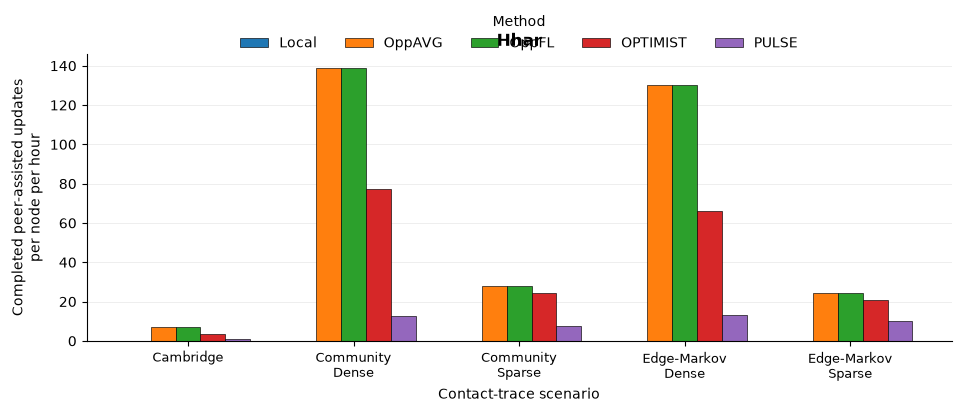

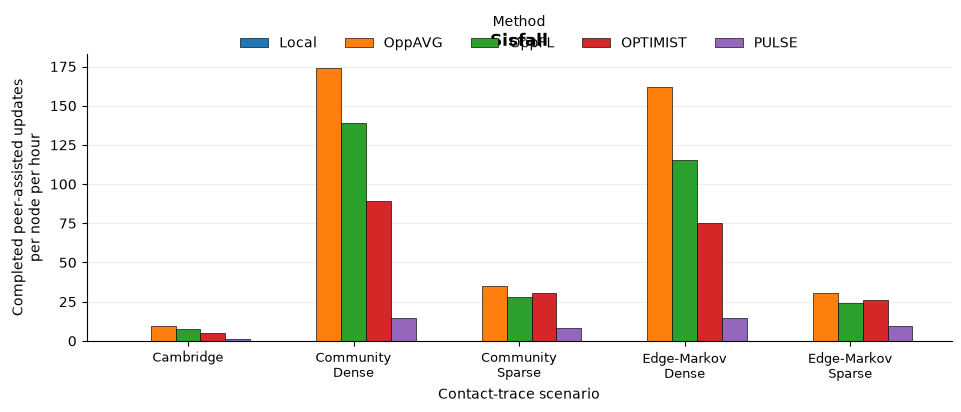

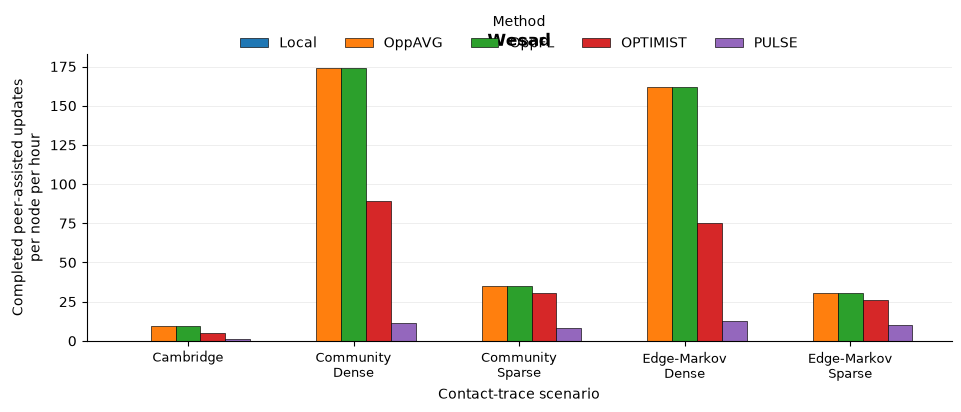

In [2]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS_ROOT = Path("./results")

DATASET_ORDER = [
    "hhar",
    "sisfall",
    "wesad",
]

ALGORITHM_ORDER = [
    "local",
    "oppavg",
    "oppfl",
    "optimist",
    "pulse",
]

ALGORITHM_LABELS = {
    "local": "Local",
    "oppavg": "OppAVG",
    "oppfl": "OppFL",
    "optimist": "OPTIMIST",
    "pulse": "PULSE",
}

SCENARIO_ORDER = [
    "cambridge",
    "community_dense",
    "community_sparse",
    "edge_markov_dense",
    "edge_markov_sparse",
]

SCENARIO_LABELS = {
    "cambridge": "Cambridge",
    "community_dense": "Community\nDense",
    "community_sparse": "Community\nSparse",
    "edge_markov_dense": "Edge-Markov\nDense",
    "edge_markov_sparse": "Edge-Markov\nSparse",
}

MOBILITY_SEED_PATTERN = re.compile(
    r"^(?P<scenario>(?:community|edge_markov)_(?:dense|sparse))"
    r"_seed(?P<seed>\d+)$"
)

if "trace_summary" not in globals():
    raise RuntimeError(
        "Run the contact-trace summary cell first to create "
        "`trace_summary`."
    )


def parse_trace_name(trace_name):
    """Return canonical scenario name and optional mobility seed."""
    if trace_name == "cambridge":
        return "cambridge", None

    match = MOBILITY_SEED_PATTERN.fullmatch(trace_name)

    if match is None:
        return None, None

    return (
        match.group("scenario"),
        int(match.group("seed")),
    )


def completed_contacts_by_seed(contacts_path):
    """Count completed peer-assisted updates for every experiment seed."""
    contacts_df = pd.read_csv(contacts_path)

    required_columns = {
        "seed",
        "requester_id",
        "peer_id",
        "details",
    }

    missing_columns = required_columns - set(contacts_df.columns)

    if missing_columns:
        raise ValueError(
            f"{contacts_path} is missing columns: "
            f"{sorted(missing_columns)}"
        )

    def is_completed(details):
        try:
            return bool(json.loads(details).get("completed", False))
        except (TypeError, json.JSONDecodeError):
            return False

    contacts_df["completed"] = contacts_df["details"].map(
        is_completed
    )

    return (
        contacts_df
        .groupby("seed", as_index=False)["completed"]
        .sum()
        .rename(columns={"completed": "completed_contacts"})
    )


contact_rows = []

for dataset_dir in sorted(RESULTS_ROOT.iterdir()):
    if not dataset_dir.is_dir():
        continue

    dataset = dataset_dir.name

    if dataset not in DATASET_ORDER:
        continue

    for trace_dir in sorted(dataset_dir.iterdir()):
        if not trace_dir.is_dir():
            continue

        scenario, mobility_seed = parse_trace_name(trace_dir.name)

        if scenario not in SCENARIO_ORDER:
            continue

        trace_info = trace_summary[
            trace_summary["trace"].eq(trace_dir.name)
        ]

        if trace_info.empty:
            print(
                f"Skipping {trace_dir.name}: trace metadata is unavailable."
            )
            continue

        trace_info = trace_info.iloc[0]

        num_nodes = int(trace_info["nodes"])
        duration_hours = float(trace_info["duration_hours"])

        for algorithm in ALGORITHM_ORDER:
            algorithm_dir = trace_dir / algorithm
            metrics_path = algorithm_dir / "metrics.csv"
            contacts_path = algorithm_dir / "contacts.csv"

            # A missing metrics file indicates a missing/incomplete run,
            # not an algorithm with zero completed peer updates.
            if not metrics_path.exists():
                continue

            metrics_df = pd.read_csv(metrics_path)

            if "seed" not in metrics_df.columns:
                raise ValueError(
                    f"{metrics_path} does not contain a seed column."
                )

            experiment_seeds = sorted(
                metrics_df["seed"].dropna().unique()
            )

            if contacts_path.exists():
                completed_by_seed = completed_contacts_by_seed(
                    contacts_path
                )

                contact_counts = dict(
                    zip(
                        completed_by_seed["seed"],
                        completed_by_seed["completed_contacts"],
                    )
                )
            else:
                # Local has no peer interactions; completed runs without
                # contacts.csv are treated as zero-contact executions.
                contact_counts = {}

            for experiment_seed in experiment_seeds:
                completed_contacts = contact_counts.get(
                    experiment_seed,
                    0,
                )

                contact_rows.append({
                    "dataset": dataset,
                    "scenario": scenario,
                    "mobility_seed": (
                        mobility_seed
                        if mobility_seed is not None
                        else "real"
                    ),
                    "algorithm": algorithm,
                    "experiment_seed": experiment_seed,
                    "completed_contacts": completed_contacts,
                    "contacts_per_node_hour": (
                        completed_contacts
                        / num_nodes
                        / duration_hours
                    ),
                })

if not contact_rows:
    raise RuntimeError(
        "No complete experiment results with metrics.csv were found."
    )

contact_runs_df = pd.DataFrame(contact_rows)

# Aggregate over experimental seeds and synthetic trace realizations.
contact_summary = (
    contact_runs_df
    .groupby(
        ["dataset", "scenario", "algorithm"],
        observed=True,
    )
    .agg(
        mean_completed_contacts=(
            "completed_contacts",
            "mean",
        ),
        std_completed_contacts=(
            "completed_contacts",
            "std",
        ),
        mean_contacts_per_node_hour=(
            "contacts_per_node_hour",
            "mean",
        ),
        std_contacts_per_node_hour=(
            "contacts_per_node_hour",
            "std",
        ),
        runs=("experiment_seed", "size"),
    )
    .reset_index()
)

contact_summary[
    [
        "std_completed_contacts",
        "std_contacts_per_node_hour",
    ]
] = contact_summary[
    [
        "std_completed_contacts",
        "std_contacts_per_node_hour",
    ]
].fillna(0.0)

display(
    contact_summary
    .sort_values(
        ["dataset", "scenario", "algorithm"]
    )
    .style
    .format({
        "mean_completed_contacts": "{:,.1f}",
        "std_completed_contacts": "{:,.1f}",
        "mean_contacts_per_node_hour": "{:.3f}",
        "std_contacts_per_node_hour": "{:.3f}",
        "runs": "{:,.0f}",
    })
    .set_caption(
        "Completed peer-assisted updates by algorithm and "
        "contact-trace scenario"
    )
)

# ------------------------------------------------------------------
# Plot one grouped bar chart for each available dataset.
# ------------------------------------------------------------------

default_colors = plt.rcParams[
    "axes.prop_cycle"
].by_key()["color"]

ALGORITHM_COLORS = {
    algorithm: color
    for algorithm, color in zip(
        ALGORITHM_ORDER,
        default_colors,
    )
}

for dataset in DATASET_ORDER:
    dataset_summary = contact_summary[
        contact_summary["dataset"].eq(dataset)
    ].copy()

    if dataset_summary.empty:
        continue

    positions = np.arange(len(SCENARIO_ORDER))
    bar_width = 0.15

    fig, ax = plt.subplots(
        figsize=(9.5, 4.0),
        constrained_layout=True,
    )

    for algorithm_index, algorithm in enumerate(ALGORITHM_ORDER):
        algorithm_summary = (
            dataset_summary[
                dataset_summary["algorithm"].eq(algorithm)
            ]
            .set_index("scenario")
            .reindex(SCENARIO_ORDER)
        )

        values = algorithm_summary[
            "mean_contacts_per_node_hour"
        ].to_numpy()

        # NaN means that the corresponding experiment is not available.
        offsets = (
            algorithm_index - (len(ALGORITHM_ORDER) - 1) / 2
        ) * bar_width

        ax.bar(
            positions + offsets,
            values,
            width=bar_width,
            label=ALGORITHM_LABELS[algorithm],
            color=ALGORITHM_COLORS[algorithm],
            edgecolor="black",
            linewidth=0.45,
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [
            SCENARIO_LABELS[scenario]
            for scenario in SCENARIO_ORDER
        ],
        fontsize=9,
    )

    ax.set_xlabel("Contact-trace scenario")
    ax.set_ylabel(
        "Completed peer-assisted updates\nper node per hour"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        alpha=0.25,
        linewidth=0.6,
    )
    ax.set_axisbelow(True)

    ax.legend(
        title="Method",
        ncol=len(ALGORITHM_ORDER),
        loc="upper center",
        bbox_to_anchor=(0.5, 1.18),
        frameon=False,
    )

    ax.set_title(
        f"{dataset.replace('_', ' ').title()}",
        fontweight="bold",
    )

    plt.show()

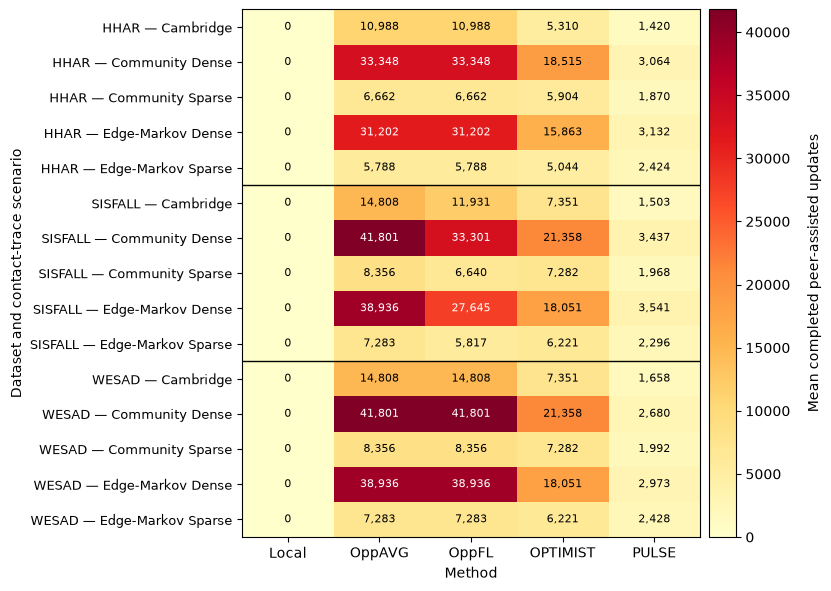

In [11]:
# ------------------------------------------------------------------
# One heatmap: total completed peer-assisted updates.
# ------------------------------------------------------------------

plot_rows = []

for dataset in DATASET_ORDER:
    for scenario in SCENARIO_ORDER:
        plot_rows.append({
            "dataset": dataset,
            "scenario": scenario,
            "row_label": (
                f"{dataset.upper()} — "
                f"{SCENARIO_LABELS[scenario].replace(chr(10), ' ')}"
            ),
        })

plot_index = pd.DataFrame(plot_rows)

heatmap_df = (
    plot_index
    .merge(
        contact_summary[
            [
                "dataset",
                "scenario",
                "algorithm",
                "mean_completed_contacts",
            ]
        ],
        on=["dataset", "scenario"],
        how="left",
    )
    .pivot(
        index="row_label",
        columns="algorithm",
        values="mean_completed_contacts",
    )
    .reindex(
        index=plot_index["row_label"],
        columns=ALGORITHM_ORDER,
    )
)

fig, ax = plt.subplots(
    figsize=(8.2, 5.8),
    constrained_layout=True,
)

values = heatmap_df.to_numpy(dtype=float)
masked_values = np.ma.masked_invalid(values)

image = ax.imshow(
    masked_values,
    aspect="auto",
    cmap="YlOrRd",
)

ax.set_xticks(np.arange(len(ALGORITHM_ORDER)))
ax.set_xticklabels(
    [ALGORITHM_LABELS[algorithm] for algorithm in ALGORITHM_ORDER],
    fontsize=10,
)

ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index, fontsize=9)

for row_index in range(values.shape[0]):
    for column_index in range(values.shape[1]):
        value = values[row_index, column_index]

        if np.isnan(value):
            label = "–"
        else:
            label = f"{value:,.0f}"

        text_color = (
            "white"
            if not np.isnan(value)
            and value > np.nanmax(values) * 0.55
            else "black"
        )

        ax.text(
            column_index,
            row_index,
            label,
            ha="center",
            va="center",
            fontsize=8,
            color=text_color,
        )

# Separate datasets visually.
for boundary in [4.5, 9.5]:
    ax.axhline(
        boundary,
        color="black",
        linewidth=1.0,
    )

colorbar = fig.colorbar(
    image,
    ax=ax,
    pad=0.02,
)
colorbar.set_label(
    "Mean completed peer-assisted updates",
    rotation=90,
    labelpad=12,
)

ax.set_xlabel("Method")
ax.set_ylabel("Dataset and contact-trace scenario")

plt.show()

In [3]:
# ------------------------------------------------------------------
# Compact table: completed peer-assisted updates.
# Requires `contact_summary` from the previous cell.
# ------------------------------------------------------------------

COMMUNICATION_ALGORITHMS = [
    "oppavg",
    "oppfl",
    "optimist",
    "pulse",
]

DATASET_SHORT_LABELS = {
    "hhar": "HAR",
    "sisfall": "FD",
    "wesad": "SR",
}

SCENARIO_SHORT_LABELS = {
    "cambridge": "C",
    "community_dense": "CD",
    "community_sparse": "CS",
    "edge_markov_dense": "EMD",
    "edge_markov_sparse": "EMS",
}

table_order = [
    (dataset, scenario)
    for dataset in DATASET_ORDER
    for scenario in SCENARIO_ORDER
]

contact_table_long = (
    contact_summary[
        contact_summary["algorithm"].isin(
            COMMUNICATION_ALGORITHMS
        )
    ]
    .copy()
)

contact_table_long["Scenario"] = (
    contact_table_long["dataset"].map(DATASET_SHORT_LABELS)
    + " – "
    + contact_table_long["scenario"].map(SCENARIO_SHORT_LABELS)
)

contact_table_long["value"] = (
    contact_table_long["mean_completed_contacts"].round().astype(int)
    .astype(str)
    + " ± "
    + contact_table_long["std_completed_contacts"].round().astype(int)
    .astype(str)
)

scenario_order_labels = [
    (
        f"{DATASET_SHORT_LABELS[dataset]} – "
        f"{SCENARIO_SHORT_LABELS[scenario]}"
    )
    for dataset, scenario in table_order
]

contact_table = (
    contact_table_long
    .pivot(
        index="Scenario",
        columns="algorithm",
        values="value",
    )
    .reindex(
        index=scenario_order_labels,
        columns=COMMUNICATION_ALGORITHMS,
    )
    .rename(
        columns={
            algorithm: ALGORITHM_LABELS[algorithm]
            for algorithm in COMMUNICATION_ALGORITHMS
        }
    )
)

display(
    contact_table
    .style
    .set_caption(
        "Mean completed peer-assisted updates "
        "(mean ± standard deviation)"
    )
    .set_properties(
        **{
            "text-align": "center",
            "white-space": "nowrap",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-weight", "bold"),
                ],
            },
        ]
    )
)

algorithm,OppAVG,OppFL,OPTIMIST,PULSE
Scenario,,,,
HAR – C,10988 ± 3761,10988 ± 3761,5310 ± 2896,1420 ± 92
HAR – CD,33348 ± 1547,33348 ± 1547,18515 ± 321,3064 ± 152
HAR – CS,6662 ± 308,6662 ± 308,5904 ± 205,1870 ± 90
HAR – EMD,31202 ± 485,31202 ± 485,15863 ± 219,3132 ± 115
HAR – EMS,5788 ± 308,5788 ± 308,5044 ± 260,2424 ± 137
FD – C,14808 ± 3355,11931 ± 3896,7351 ± 2911,1503 ± 21
FD – CD,41801 ± 294,33301 ± 1071,21358 ± 176,3437 ± 1296
FD – CS,8356 ± 132,6640 ± 249,7282 ± 96,1968 ± 267
FD – EMD,38936 ± 447,27645 ± 8567,18051 ± 274,3541 ± 196
